# HF 匹配与Compton背景提取
流程：结合能阈值和有限表格 f-sum → 同窗口面积预匹配 → HF 比例与线性项拟合 → 价电子轮廓 → 保留近边的扣除。

In [11]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from xrs_compton_extraction.exploratory import (
    read_crystals, atomic_audit, reference_scores,
    prompt_pz, prompt_energy, prompt_coordinates, valence_stages,
    map_available, fit_unweighted_pearson, fit_unweighted_templates, save_result,
)
from xrs_compton_extraction.backgrounds import DabaxProfileSource, build_core_profile
from xrs_compton_extraction.backgrounds.valence_profile import ValenceReferenceCandidate
from xrs_compton_extraction.geometry import energy_loss_to_pz, pz_to_energy_loss
from xrs_compton_extraction.constants import HARTREE_ENERGY_EV
from xrs_compton_extraction.hf_workflow import build_hf_energy, match_hf_scale, extract_hf_target

cwd = Path.cwd().resolve()
ROOT = next(p for p in [cwd, *cwd.parents] if (p / "workspace" / "Ho").exists())
PACKAGE = ROOT / "xrs-compton-extraction"
DATA = ROOT / "workspace/Ho/processed/Ho_Comptonscan_standard"
PROFILE_TABLE = PACKAGE / "resources/compton_profiles/ComptonProfiles.dat"
OUTPUT = PACKAGE / "output/ho-b4-hf-matching"
REAL, SYNTHETIC = OUTPUT / "real", OUTPUT / "synthetic"
for directory in (REAL, SYNTHETIC):
    directory.mkdir(parents=True, exist_ok=True)

# 所有可调物理参数集中在此。None 表示尚未确定，不能默认补值。
EDGE = (111.0, 211.0)
WINDOWS = ((20.0, 80.0), (230.0, 500.0))
MINIMUM_ENERGY = 20.0
TAIL = (230.0, 500.0)
SMOOTH_SIGMA = 0.05  # pz 原子单位；非对称拟合关闭
PRENORM_WINDOWS = ((20.0, 500.0),)  # HF 与实验同支持，排除 EDGE
HF = dict(composition={"Ho": 1, "B": 4}, target=("Ho", "Shell_13"),
          valence_cutoff_ev=20.0, integration_points=16001, fit_linear=True)
# Ho N4 = Shell_13，4电子，164 eV；N5 = Shell_14，161 eV。
# 显式采用 XRStools 的 binding < 20 eV 价电子划分（20 eV 边界归芯层）。
# 这是可调的探索假设，不是 HoB4 价电子结构的实验验证。
display({"HF": HF, "protection": EDGE, "fit_windows": WINDOWS,
         "prenorm_windows": PRENORM_WINDOWS})


{'HF': {'composition': {'Ho': 1, 'B': 4},
  'target': ('Ho', 'Shell_13'),
  'valence_cutoff_ev': 20.0,
  'integration_points': 16001,
  'fit_linear': True},
 'protection': (111.0, 211.0),
 'fit_windows': ((20.0, 80.0), (230.0, 500.0)),
 'prenorm_windows': ((20.0, 500.0),)}

## 1. 分析晶体与处理记录

强度表提供晶体标签；fit-results 提供各晶体元数据；run-info 提供处理记录。


In [12]:
prefix = DATA / "Ho_Comptonscan_standard"
dataset, records, provenance = read_crystals(
    str(prefix) + "_all_data.txt",
    str(prefix) + "_fit_results.txt",
    str(prefix) + "_run_info.json",
)
crystals = pd.DataFrame(records)
spectra = {s.analyzer_id: s for s in dataset.spectra}
display(crystals[["crystal", "module", "center_eV", "fwhm_eV", "q_ave",
                  "q_au", "dq_ave", "q_range", "dq_range", "group", "all_zero"]])
display(provenance["run_info"]["config"])
crystals.to_csv(REAL / "crystals.csv", index=False)
(REAL / "input-audit.json").write_text(
    json.dumps(provenance, indent=2, ensure_ascii=False), encoding="utf-8")
print("保留通道:", len(records), "全零通道:", crystals.loc[crystals.all_zero, "crystal"].tolist())


,crystal,module,center_eV,fwhm_eV,q_ave,q_au,dq_ave,q_range,dq_range,group,all_zero
0,VB-A1,VB,9681.874325,1.062630,9.840563,5.207402,0.087333,0.405056,0.003449,mid_high_q,False
1,VB-A2,VB,9683.487584,1.278320,9.859149,5.217237,0.082848,0.405757,0.003272,mid_high_q,False
2,VB-A3,VB,9686.209367,1.050648,9.842720,5.208543,0.087353,0.405053,0.003450,mid_high_q,False
3,VB-B1,VB,9680.888845,1.039392,9.714196,5.140531,0.114008,0.400088,0.004499,mid_high_q,False
4,VB-B2,VB,9682.857838,1.670831,9.732225,5.150072,0.110798,0.400759,0.004373,mid_high_q,False
5,VB-B3,VB,9684.855156,1.609086,9.716143,5.141561,0.114031,0.400083,0.004501,mid_high_q,False
6,VB-C1,VB,9679.749674,0.742176,9.551706,5.054545,0.140726,0.393702,0.005549,mid_high_q,False
7,VB-C2,VB,9681.157788,0.817414,9.568511,5.063438,0.138325,0.394335,0.005455,mid_high_q,False
8,VB-C3,VB,9683.117175,0.870484,9.553330,5.055405,0.140751,0.393695,0.005551,mid_high_q,False
9,VB-D1,VB,9681.255400,0.943265,9.355039,4.950473,0.167185,0.385918,0.006587,mid_high_q,False


{'dataset': 'Ho',
 'elastic_scan_ids': [57],
 'xrs_scan_ids': [59],
 'excluded_xrs_scan_ids': [],
 'detectors': {'lambda': {'roi_file': 'roi_60crystals-v3.txt'},
  'minipix': {'roi_file': 'roi_minipix-v3.txt'}},
 'energy_pv_candidates': ['M_DCM_B5Energy_readback',
  'M_DCM_B5Link_Energy_readback'],
 'i0_pv': 'D_SiC_I_A',
 'divide_i0_elastic': True,
 'divide_i0_xrs': True,
 'remove_i0_glitches': True,
 'i0_glitch_ratio': 0.7,
 'use_filter': True,
 'auto_adjust_roi': True,
 'roi_size': 30,
 'filter_fraction': 0.15,
 'initial_module_shifts': {'lambda': {'VU': [5, 10], 'VD': [-10, 20]},
  'minipix': {}},
 'fit_energy_bounds_kev': [9.67, 9.69],
 'max_fwhm_ev': 2.0,
 'min_r_squared': 0.8,
 'module_angles_deg': {'VB': 145.6,
  'VU': 79.03,
  'VD': 25.0,
  'HB': 118.8,
  'HL': 58.85,
  'HR': 67.862},
 'included_modules': ['VB', 'HB', 'HL', 'VD', 'VU'],
 'q_range_inverse_angstrom': [0.0, 10.0],
 'manual_excluded_crystals': [],
 'interpolation_step_ev': 0.2,
 'plot_log_intensity': False,
 'elast

保留通道: 52 全零通道: ['HB-E1', 'HB-E2']


## 2. 能量原轴和 q 分组诊断


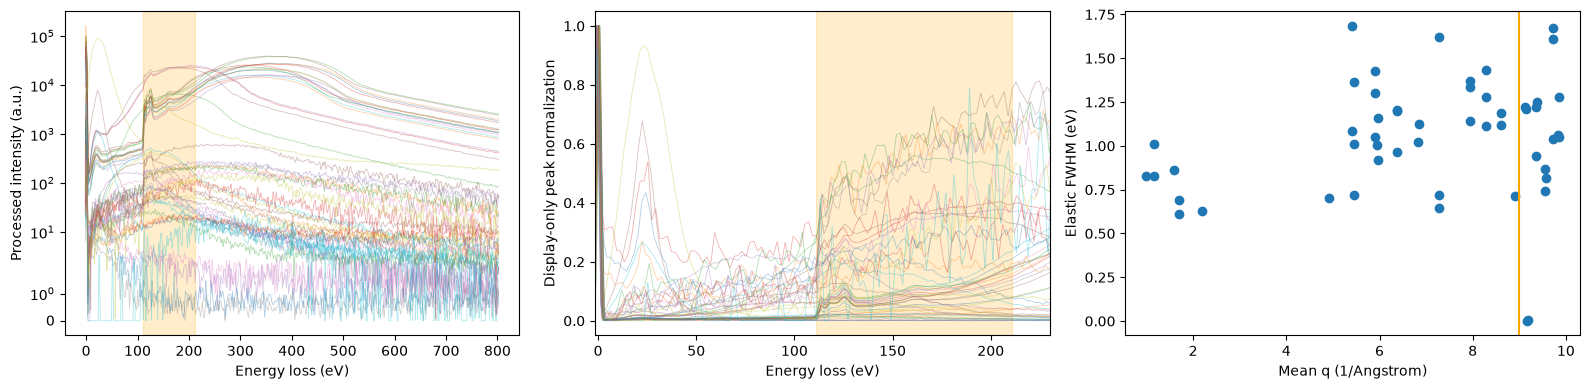

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for record in records:
    s = spectra[record["crystal"]]
    if record["all_zero"]:
        continue
    axes[0].plot(s.energy_loss_ev, s.counts, alpha=.35, lw=.6)
    axes[1].plot(s.energy_loss_ev, s.counts / max(np.max(s.counts), 1), alpha=.35, lw=.6)
axes[0].set(xlabel="Energy loss (eV)", ylabel="Processed intensity (a.u.)", yscale="symlog")
axes[1].set(xlim=(-1.6, 230), xlabel="Energy loss (eV)", ylabel="Display-only peak normalization")
for ax in axes[:2]:
    ax.axvspan(*EDGE, color="orange", alpha=.2)
axes[2].scatter(crystals.q_ave, crystals.fwhm_eV)
axes[2].axvline(9, color="orange")
axes[2].set(xlabel="Mean q (1/Angstrom)", ylabel="Elastic FWHM (eV)")
fig.tight_layout()
fig.savefig(REAL / "overview.png", dpi=150)
plt.show()


## 3. Hatree-Fock 查表法 与 能量域 HF

In [14]:
source = DabaxProfileSource(PROFILE_TABLE)
atomic_rows, atomic_summary = atomic_audit(source)
display(pd.DataFrame(atomic_rows))
display(pd.DataFrame(atomic_summary))
assert source.binding_energy_ev("Ho", "Shell_13") == 164.0
atomic_metadata = {"backend": dict(source.provenance), "summaries": atomic_summary,
                   "target": "Ho N4 = Shell_13", "scientifically_validated": False}
pd.DataFrame(atomic_rows).to_csv(REAL / "atomic-shell-audit.csv", index=False)
(REAL / "atomic-audit.json").write_text(
    json.dumps(atomic_metadata, indent=2, ensure_ascii=False), encoding="utf-8")

def make_hf(energy, q):
    return build_hf_energy(energy, q, source, HF["composition"], target=HF["target"],
        valence_cutoff_ev=HF["valence_cutoff_ev"], integration_points=HF["integration_points"])

example_hf = make_hf(next(iter(spectra.values())).energy_loss_ev, 5.0)
display(pd.DataFrame(example_hf.metadata["shells"]).T)
print("本次模型价电子数/HoB4:", example_hf.metadata["valence_electron_count"])


,element,shell,occupancy,binding_energy_eV,partial_full_integral_to_100_au
0,Ho,Shell_1,2.0,55620.0,0.987210
1,Ho,Shell_2,2.0,9395.0,1.017637
2,Ho,Shell_3,2.0,8918.0,1.031056
3,Ho,Shell_4,4.0,8071.0,1.026095
4,Ho,Shell_5,2.0,2123.0,1.012235
5,Ho,Shell_6,2.0,1918.0,1.022463
6,Ho,Shell_7,4.0,1736.0,1.022161
7,Ho,Shell_8,4.0,1386.0,1.023382
8,Ho,Shell_9,6.0,1346.0,1.027618
9,Ho,Shell_10,2.0,431.0,1.017417


,element,atomic_number,available_occupancy_sum,electron_count_difference,relative_profile_l2_difference,total_full_integral_to_100_au,status
0,Ho,67,67.0,0.0,0.002714,67.972376,requires explicit table/occupation review
1,B,5,5.0,0.0,0.000861,5.034905,requires explicit table/occupation review


,binding_energy_eV,electron_count,kind,fsum_scale,normalization_upper_energy_eV,status
Ho:Shell_1,55620.0,2.0,core,None,13945.835451,threshold_outside_table_support
Ho:Shell_2,9395.0,2.0,core,5.737697,13945.835451,finite_table_fsum
Ho:Shell_3,8918.0,2.0,core,9.070428,13945.835451,finite_table_fsum
Ho:Shell_4,8071.0,4.0,core,22.966445,13945.835451,finite_table_fsum
Ho:Shell_5,2123.0,2.0,core,2.974789,13945.835451,finite_table_fsum
Ho:Shell_6,1918.0,2.0,core,2.451399,13945.835451,finite_table_fsum
Ho:Shell_7,1736.0,4.0,core,4.839053,13945.835451,finite_table_fsum
Ho:Shell_8,1386.0,4.0,core,2.597175,13945.835451,finite_table_fsum
Ho:Shell_9,1346.0,6.0,core,3.86508,13945.835451,finite_table_fsum
Ho:Shell_10,431.0,2.0,core,2.005308,13945.835451,finite_table_fsum


本次模型价电子数/HoB4: 25.0


## 4. 参考选择与自动强度标定
候选 q、清洁比例、尾部覆盖三项等权评分。先令 I_pre=I_raw×area(HF)/area(I_raw)，双方均在相同有效窗口积分且不跨越保护区。
再拟合 I_pre=a HF_total+b0+b1(E−Ec)，a>0，得到 (I_pre−linear)/a。
提取参考价电子时减全部 HF 芯层，并用遮罩修复目标结构；最终提取 N4 时只减其他芯层。
不再要求人工输入 reference_scale 或 reference_constant。


In [15]:
scores = reference_scores(dataset, records, edge=EDGE, minimum_energy=MINIMUM_ENERGY, tail=TAIL)
display(pd.DataFrame(scores))
pd.DataFrame(scores).to_csv(REAL / "reference-scores.csv", index=False)
reference = None
reference_failures = []
reference_metadata = None
for row in scores:
    label = row["crystal"]
    s = spectra[label]
    q = next(r["q_au"] for r in records if r["crystal"] == label)
    keep = s.energy_loss_ev >= MINIMUM_ENERGY
    energy, intensity = s.energy_loss_ev[keep], s.counts[keep]
    try:
        ref_hf = make_hf(energy, q)
        matched = match_hf_scale(energy, intensity, ref_hf.total, windows=WINDOWS,
            edge=EDGE, prenorm_windows=PRENORM_WINDOWS, fit_linear=HF["fit_linear"])
        candidate = ValenceReferenceCandidate(
            label, energy, matched["calibrated"], q,
            (energy >= EDGE[0]) & (energy <= EDGE[1]), core_background=ref_hf.core,
            provenance={"matching": matched["metadata"], "hf": ref_hf.metadata})
        profile, stages = valence_stages(candidate, ref_hf.metadata["valence_electron_count"], SMOOTH_SIGMA)
        reference = (profile, stages)
        reference_metadata = {"crystal": label, "matching": matched["metadata"],
            "hf": ref_hf.metadata, "profile_diagnostics": dict(profile.diagnostics),
            "negative_profile_points_retained": int(np.sum(profile.profile < 0)),
            "support_pz_package_au": profile.support_intervals_pz_au,
            "note": "finite-support normalization; shared covariance unavailable"}
        break
    except (ValueError, FloatingPointError) as exc:
        reference_failures.append({"crystal": label, "reason": str(exc)})
display(reference_metadata)
display(reference_failures)
(REAL / "hf-status.json").write_text(json.dumps({
    "reference_failures": reference_failures, "selected": reference_metadata,
    "parameters": HF, "scientifically_validated": False,
}, indent=2, ensure_ascii=False, allow_nan=False), encoding="utf-8")


,crystal,q_score,clean_fraction,tail_coverage,score
0,VB-A2,1.000000,0.871965,1.0,0.957322
1,VB-A3,0.998334,0.871965,1.0,0.956766
2,VB-A1,0.998115,0.871965,1.0,0.956693
3,VB-B2,0.987126,0.871965,1.0,0.953031
4,VB-B3,0.985495,0.871965,1.0,0.952487
5,VB-B1,0.985298,0.871965,1.0,0.952421
6,VB-C2,0.970521,0.871965,1.0,0.947495
7,VB-C3,0.968981,0.871965,1.0,0.946982
8,VB-C1,0.968816,0.871965,1.0,0.946927
9,VB-D2,0.950424,0.871965,1.0,0.940796


{'crystal': 'VB-A3',
 'matching': {'area_pre_scale': 3.087969342559075e-06,
  'data_area': 8497844.760685299,
  'hf_area': 26.241084098822462,
  'fitted_hf_scale': 0.6964071088743937,
  'raw_to_hf_scale': 4.434143912675124e-06,
  'baseline_intercept_pre': 0.023975329008899506,
  'baseline_slope_pre_per_eV': 8.050287259316605e-05,
  'baseline_center_eV': 307.60593220338984,
  'fit_linear': True,
  'windows_ev': [(20.0, 80.0), (230.0, 500.0)],
  'prenorm_windows_ev': [(20.0, 500.0)],
  'protected_window_ev': [111.0, 211.0],
  'fit_rmse_per_eV': 0.014763424330902138,
  'statistical_uncertainty': None,
  'parameter_covariance': None},
 'hf': {'source': {'provider': 'local_dabax',
   'source_file': 'C:\\Users\\a1566\\Documents\\Work\\python\\xrsabre\\xrs-compton-extraction\\resources\\compton_profiles\\ComptonProfiles.dat',
   'source_sha256': 'db42c6cefad0916886e96acf03b0186b538d01dbde2988d7bdec4c8675d814ba',
   'table_date': 'Wed Jan 29 16:17:10 2003',
   'reference_doi': '10.1016/0092-64

[{'crystal': 'VB-A2',
  'reason': 'profile has a non-positive signed normalization integral'}]

9790

## 5. 价电子 pz 轮廓
显示 pz=q/2−ω/q，与包内符号相反，强度与坐标同步反射排序。
J=(匹配后的密度−HF_core)×q×Hartree_eV。分别保存原始、对称及平滑轮廓；
在有限共同支持内归一化至本次模型电子数，不外推未观测尾部。
负值保留且统计；较多负值提示模型/窗口失配，优化器运行成功不是科学验收。


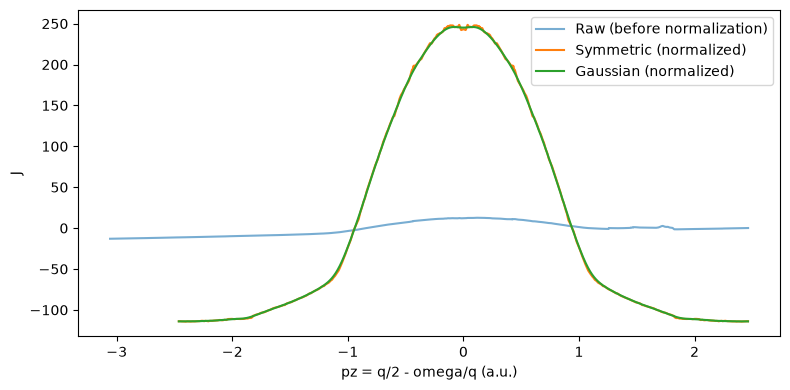

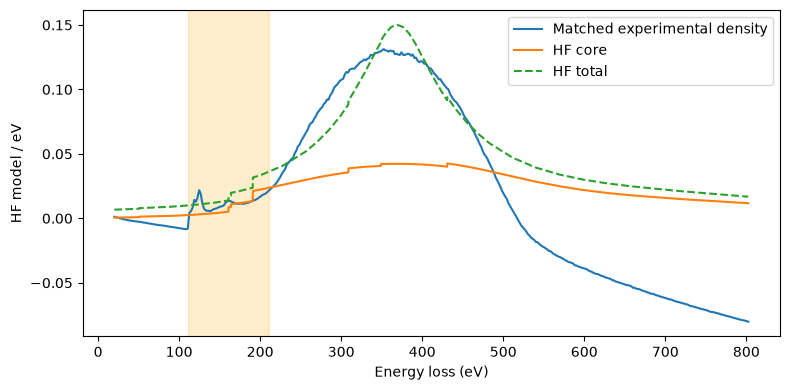

In [16]:
def show_stages(stages, directory):
    pd.DataFrame({"pz_prompt_au": stages["pz_raw"], "J_raw": stages["raw"],
                  "interpolated_mask": stages["mask"]}).to_csv(directory / "valence-raw.csv", index=False)
    pd.DataFrame({"pz_prompt_au": stages["pz"], "J_sym": stages["symmetric"],
                  "J_corrected": stages["corrected"]}).to_csv(directory / "valence-stages.csv", index=False)
    (directory / "stage-scales.json").write_text(json.dumps({
        "sym_normalization_scale": stages["sym_normalization_scale"],
        "smooth_normalization_scale": stages["smooth_normalization_scale"],
        "gaussian_sigma_pz_au": SMOOTH_SIGMA, "asymmetry_mode": "off",
        "unobserved_tails_estimated": False,
        "interpolated_pz_samples": stages["pz_raw"][stages["mask"]].tolist(),
    }, indent=2), encoding="utf-8")
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(stages["pz_raw"], stages["raw"], label="Raw (before normalization)", alpha=.6)
    ax.plot(stages["pz"], stages["symmetric"], label="Symmetric (normalized)")
    ax.plot(stages["pz"], stages["corrected"], label="Gaussian (normalized)")
    ax.set(xlabel="pz = q/2 - omega/q (a.u.)", ylabel="J")
    ax.legend()
    fig.tight_layout()
    fig.savefig(directory / "valence-stages.png", dpi=150)
    plt.show()

if reference is not None:
    show_stages(reference[1], REAL)
    pd.DataFrame({"energy_eV": candidate.energy_loss_ev,
                  "calibrated_density_per_eV": candidate.corrected_intensity,
                  "HF_density_per_eV": candidate.core_background,
                  "edge_mask": candidate.contamination_mask}).to_csv(
        REAL / "reference-hf-subtraction.csv", index=False)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(candidate.energy_loss_ev, candidate.corrected_intensity, label="Matched experimental density")
    ax.plot(candidate.energy_loss_ev, candidate.core_background, label="HF core")
    ax.plot(candidate.energy_loss_ev, ref_hf.total, "--", label="HF total")
    ax.axvspan(*EDGE, color="orange", alpha=.2)
    ax.set(xlabel="Energy loss (eV)", ylabel="HF model / eV")
    ax.legend()
    fig.tight_layout()
    fig.savefig(REAL / "reference-hf.png", dpi=150)
    plt.show()
else:
    print("真实轮廓暂停；下方合成数据仍可展示完整流程。")


## 6. 保留 目标边 的逐通道提取
高 q 使用全部 HF_core+价电子拟合比例和基线，但只扣除 other_core+valence+linear。
高 q 为 HF 模型密度/eV，低 q Pearson 保持任意单位，不能直接混合平均。



,crystal,status,model,fit_rmse,units,reason
0,VB-A1,exploratory,hf_target_preserving,0.062216,"HF-model density per eV; exploratory, not abso...",NaN
1,VB-A2,exploratory,hf_target_preserving,0.100253,"HF-model density per eV; exploratory, not abso...",NaN
2,VB-A3,exploratory,hf_target_preserving,0.051631,"HF-model density per eV; exploratory, not abso...",NaN
3,VB-B1,exploratory,hf_target_preserving,0.074512,"HF-model density per eV; exploratory, not abso...",NaN
4,VB-B2,exploratory,hf_target_preserving,0.064510,"HF-model density per eV; exploratory, not abso...",NaN
5,VB-B3,exploratory,hf_target_preserving,0.048002,"HF-model density per eV; exploratory, not abso...",NaN
6,VB-C1,exploratory,hf_target_preserving,0.056013,"HF-model density per eV; exploratory, not abso...",NaN
7,VB-C2,exploratory,hf_target_preserving,0.051256,"HF-model density per eV; exploratory, not abso...",NaN
8,VB-C3,exploratory,hf_target_preserving,0.046213,"HF-model density per eV; exploratory, not abso...",NaN
9,VB-D1,exploratory,hf_target_preserving,0.062634,"HF-model density per eV; exploratory, not abso...",NaN


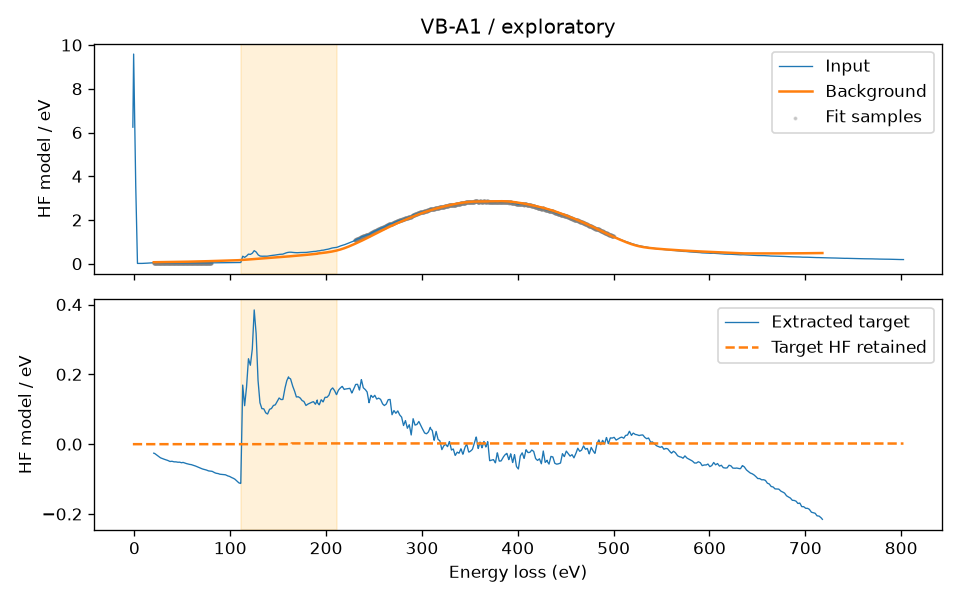

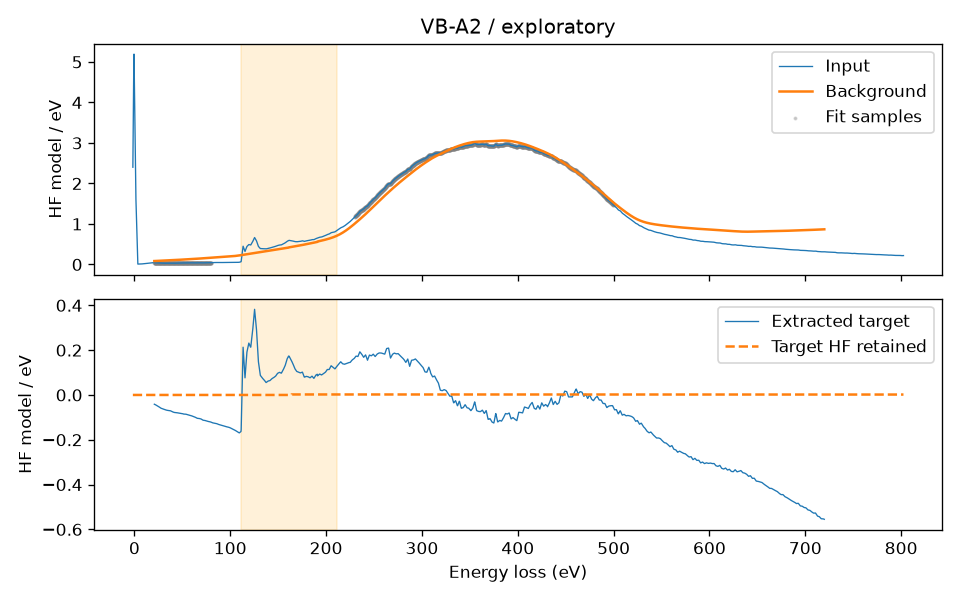

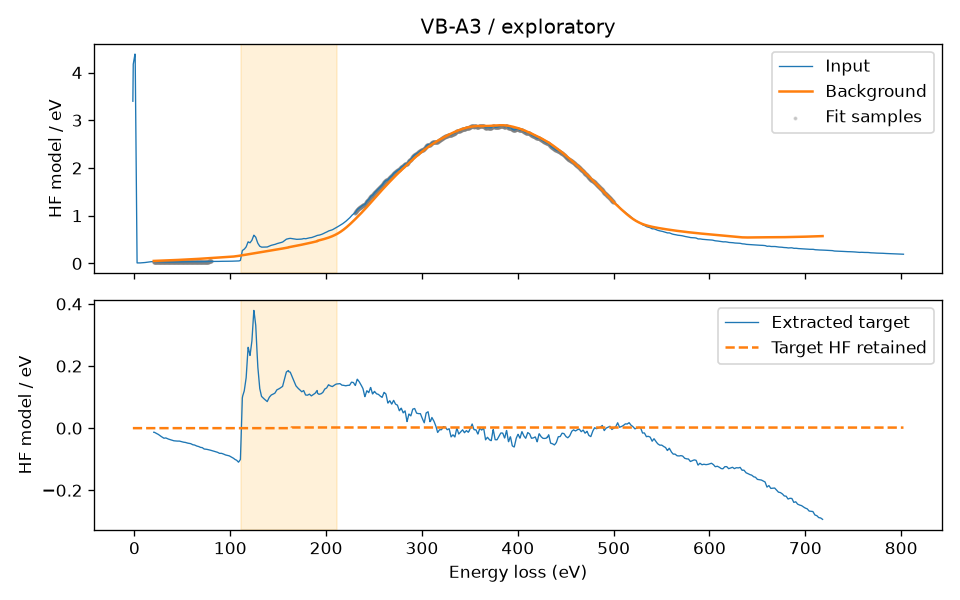

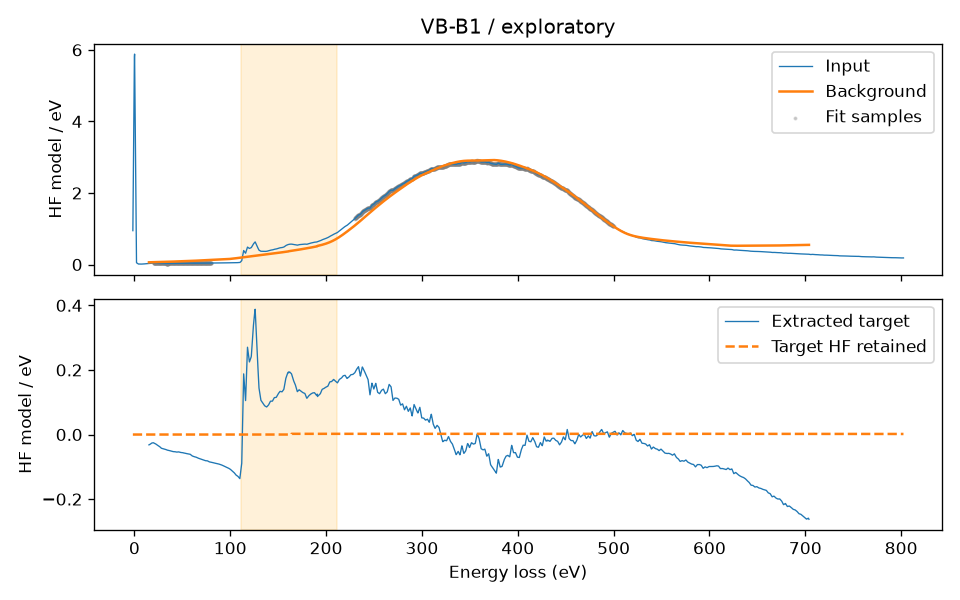

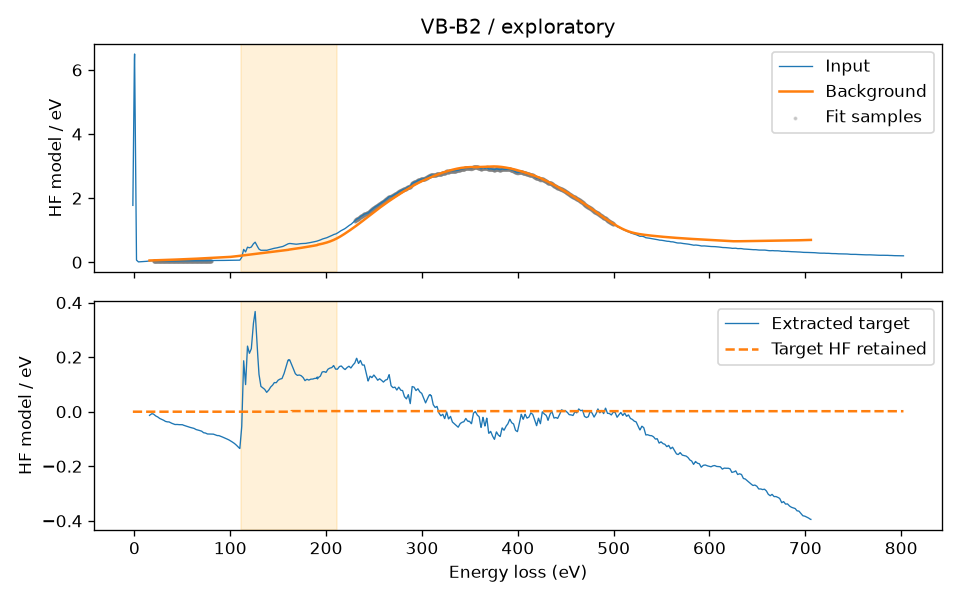

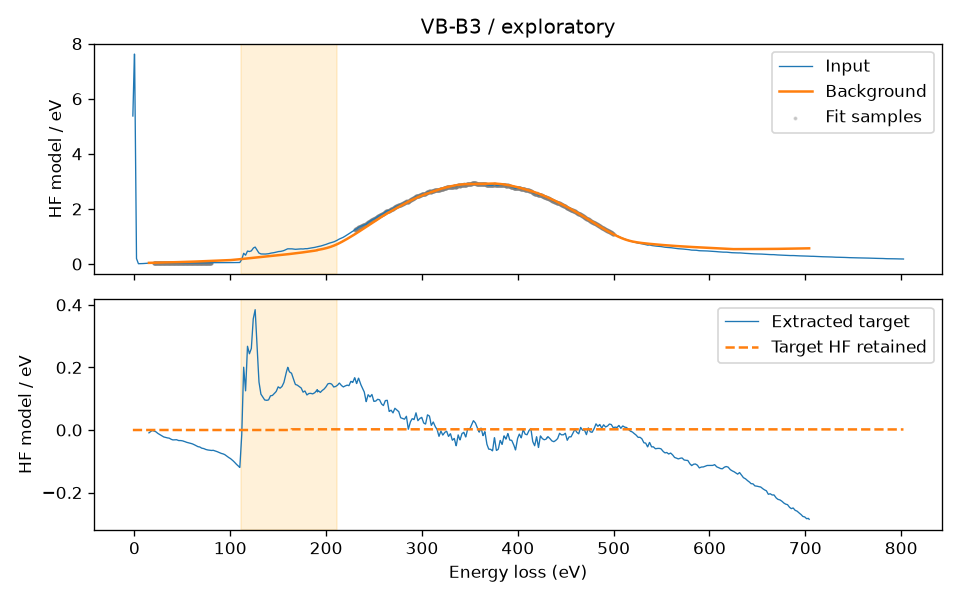

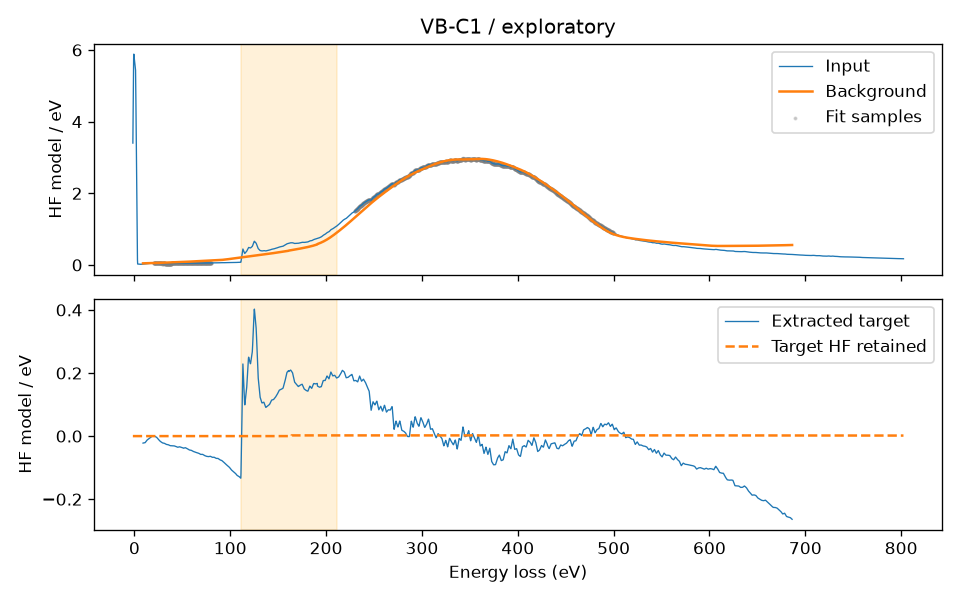

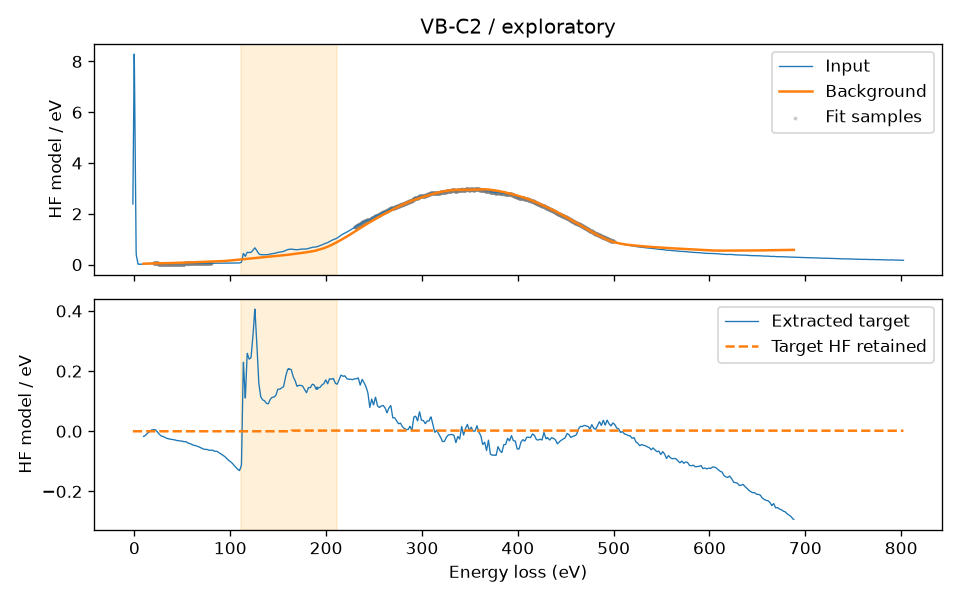

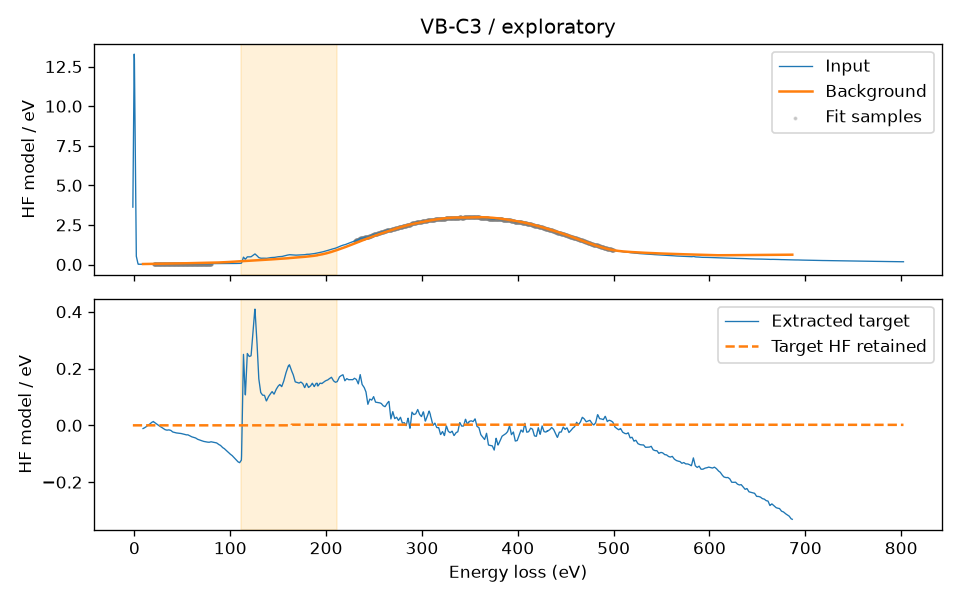

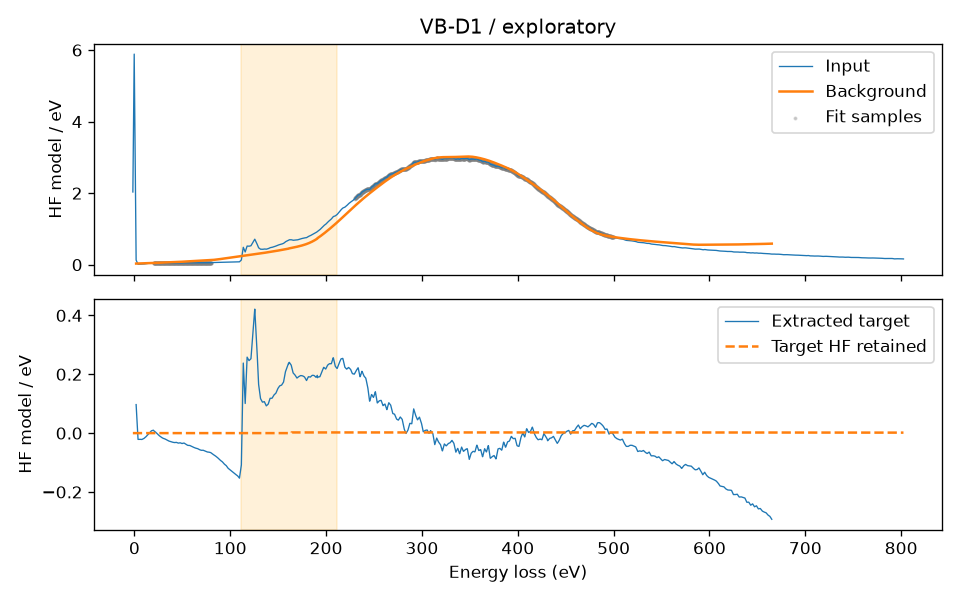

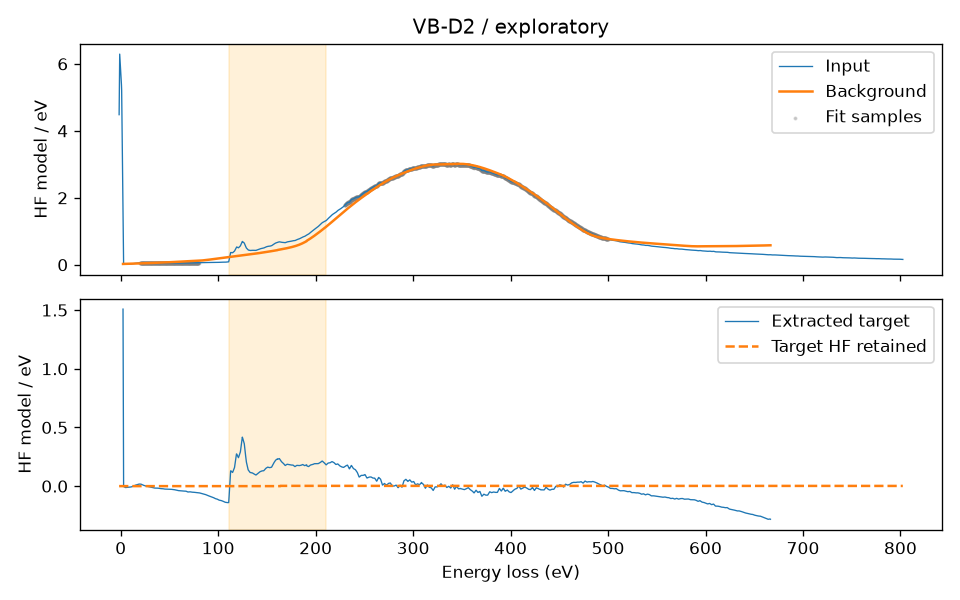

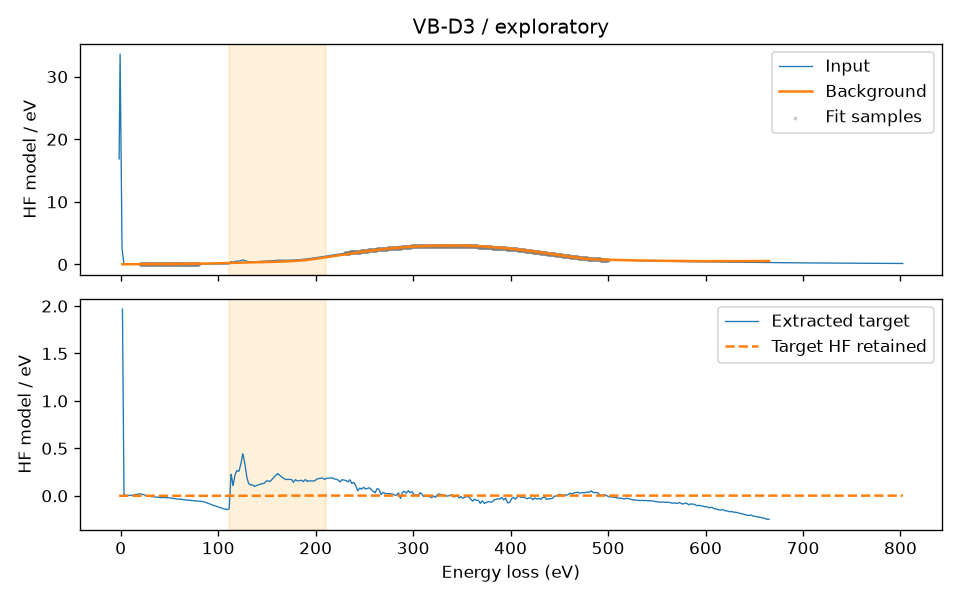

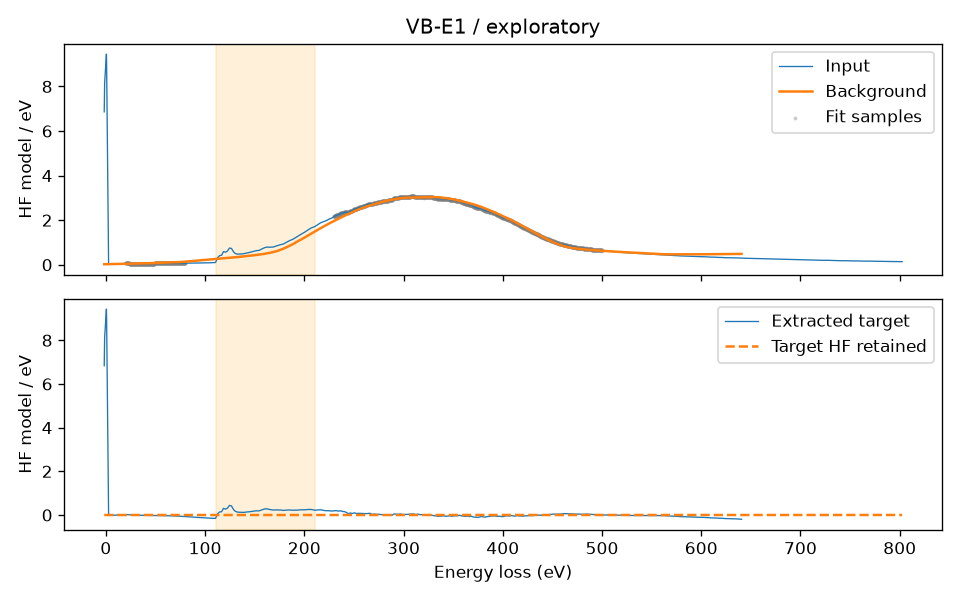

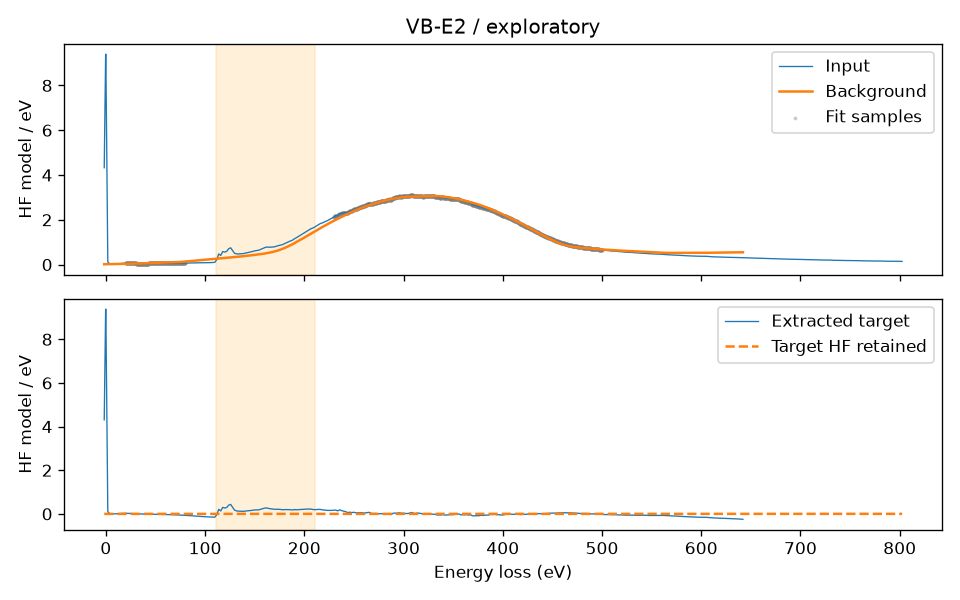

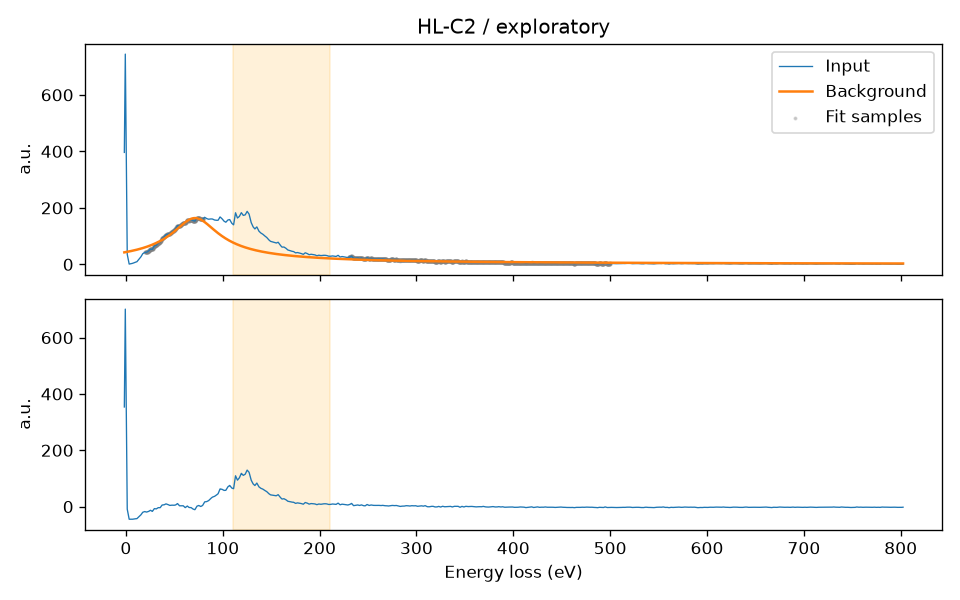

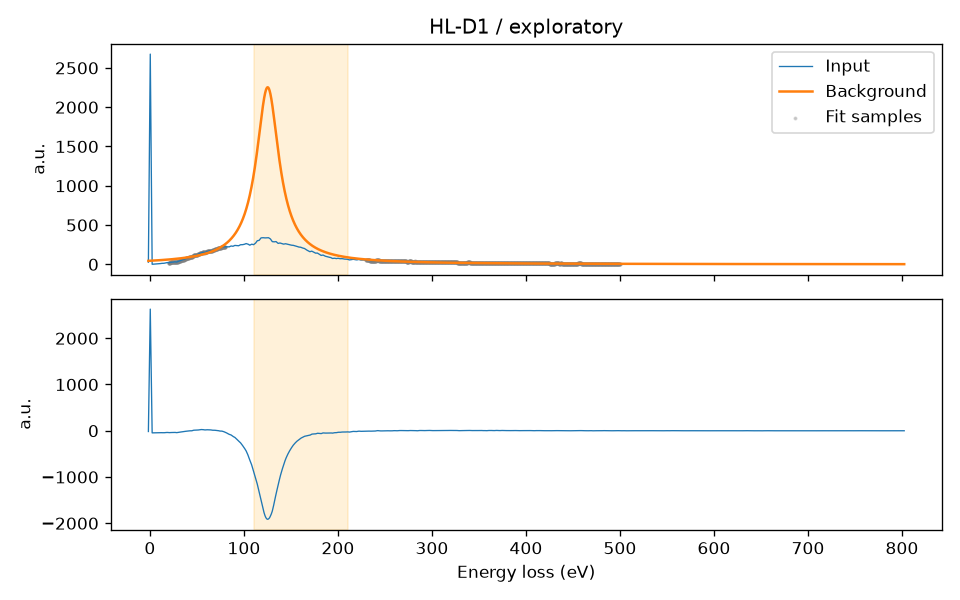

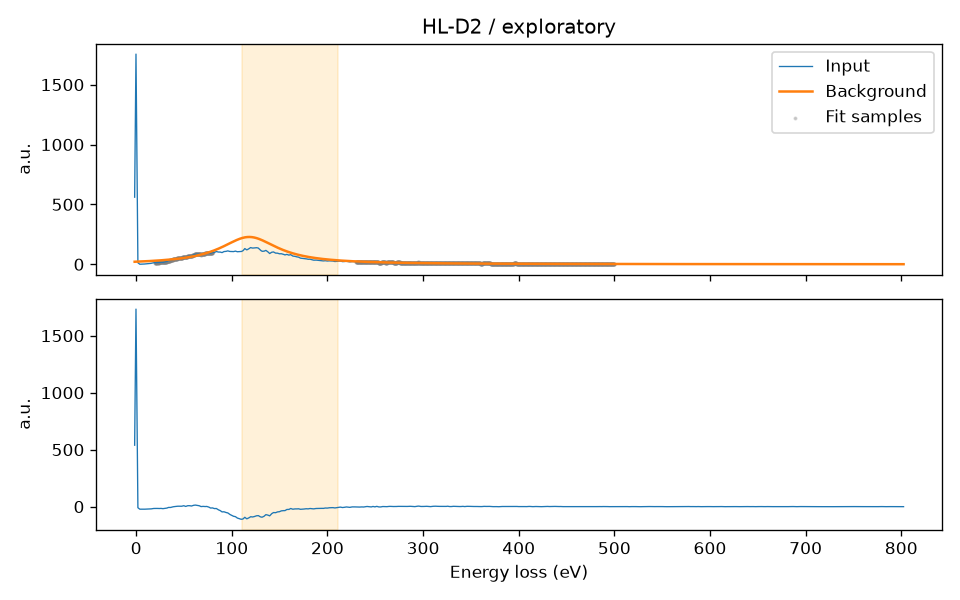

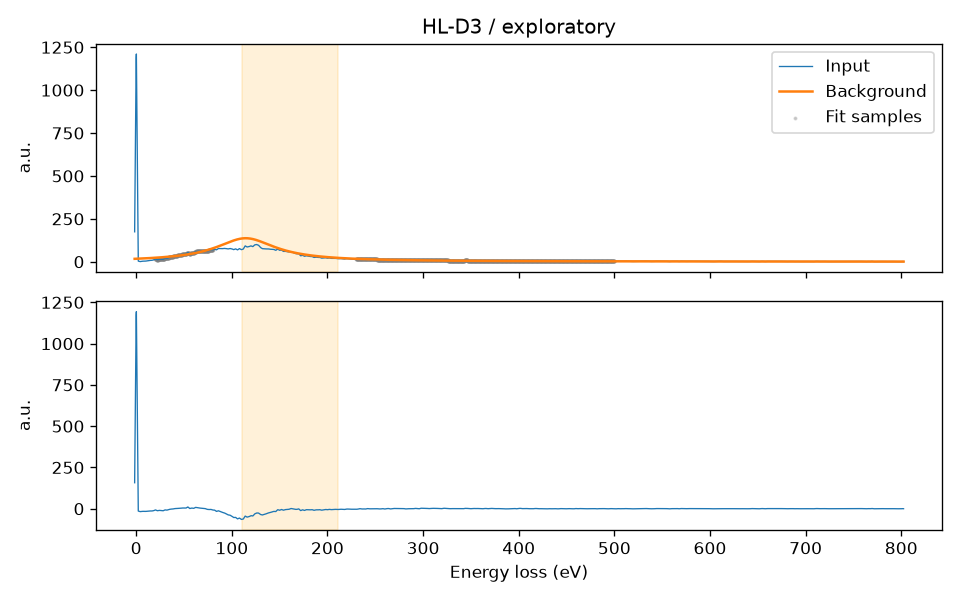

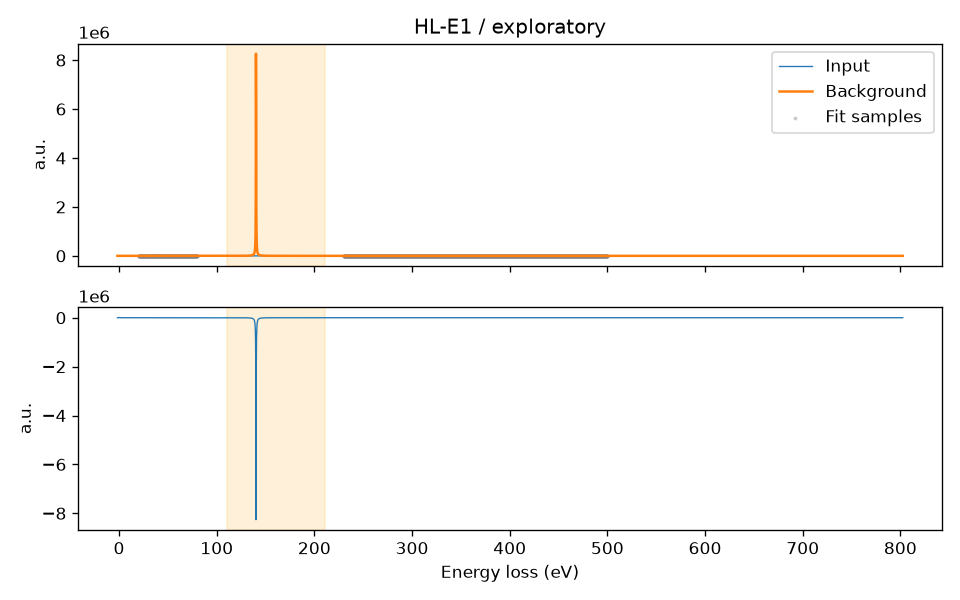

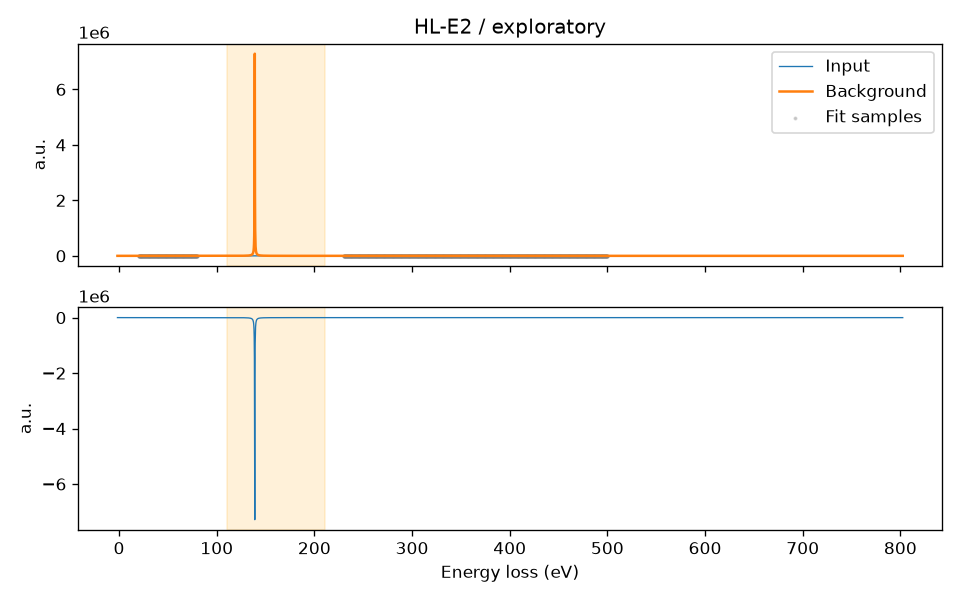

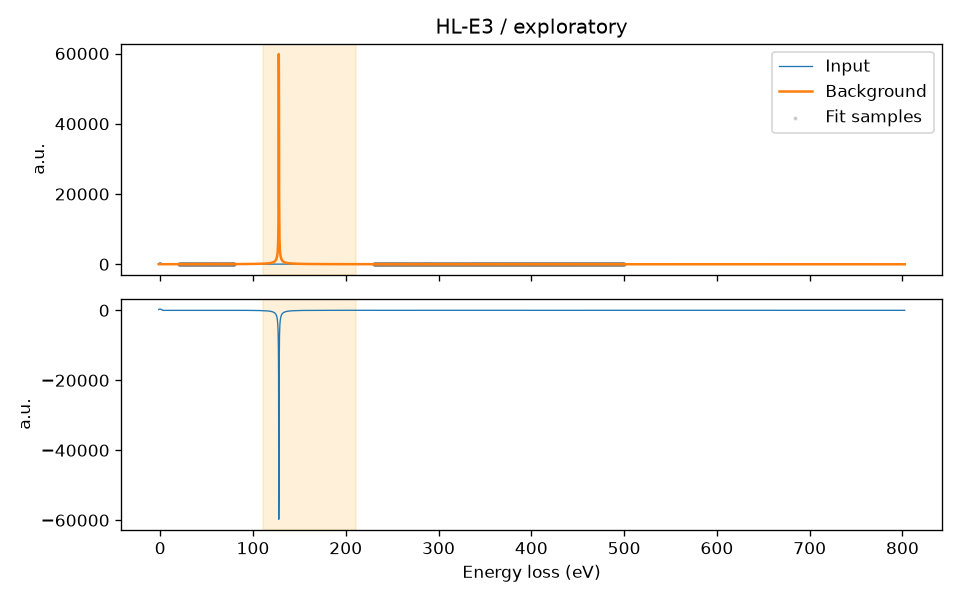

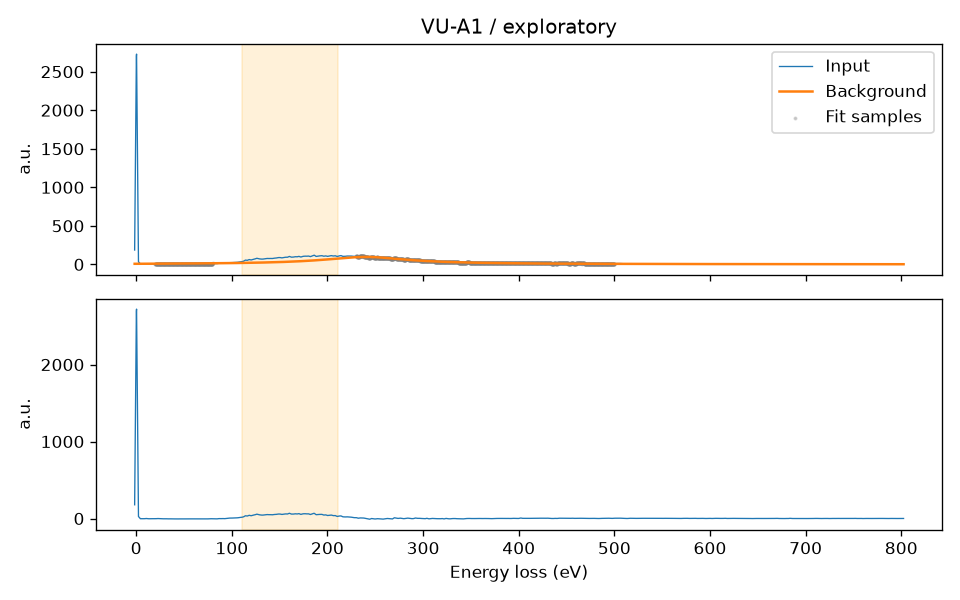

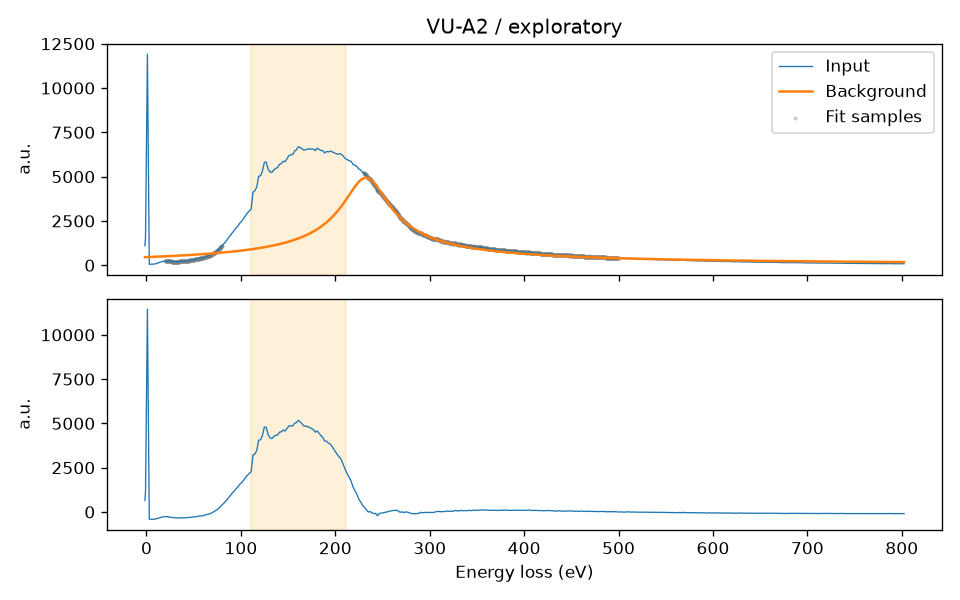

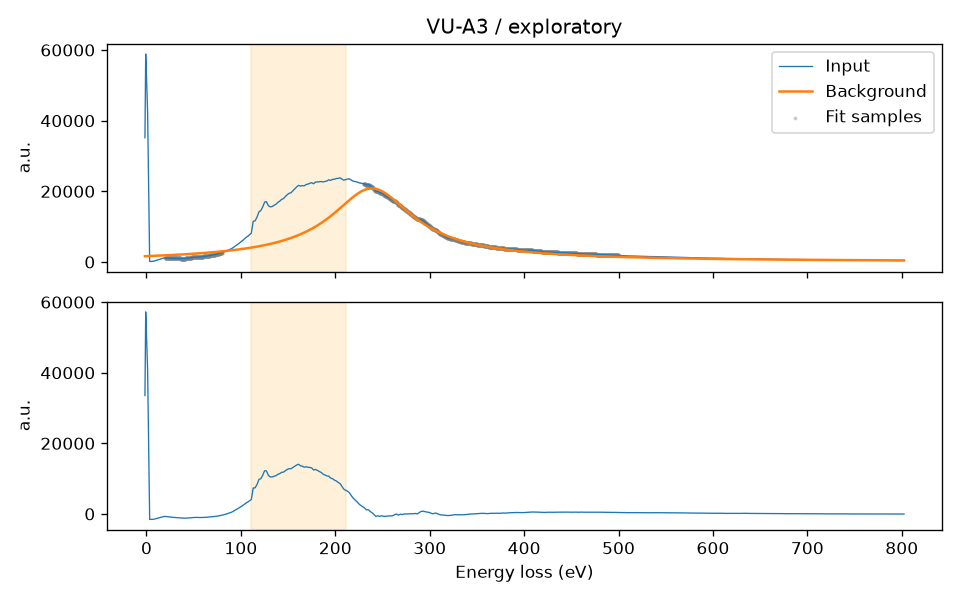

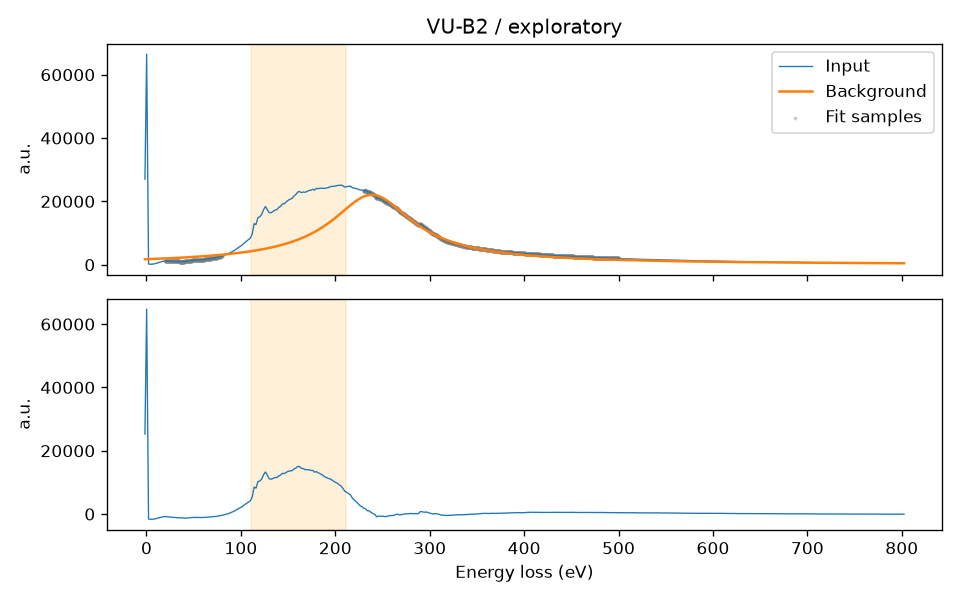

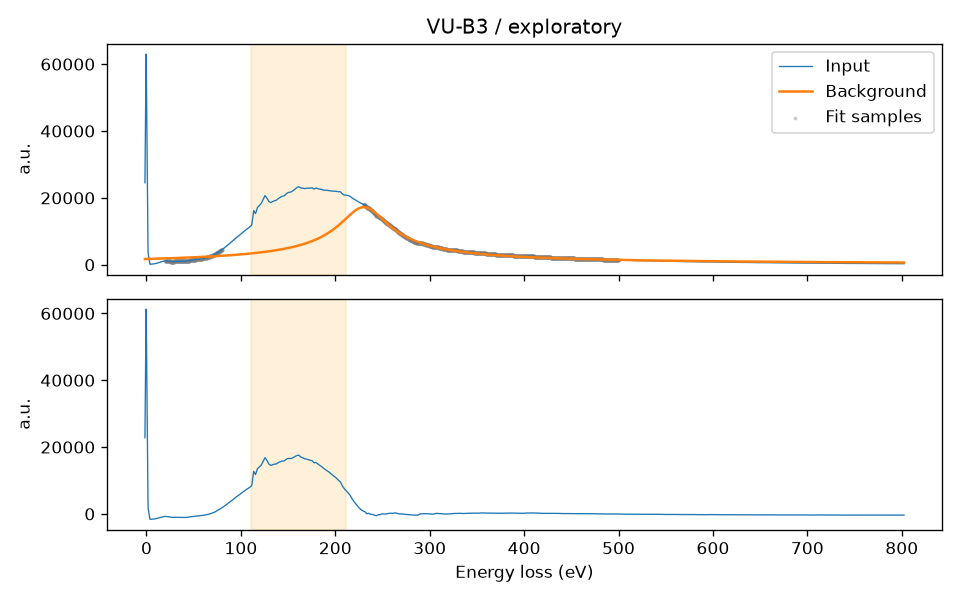

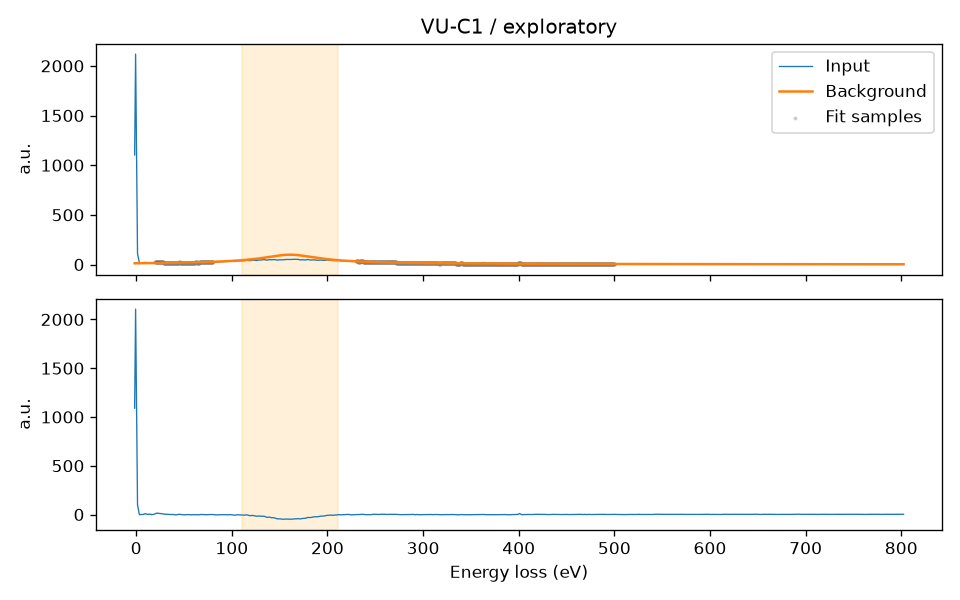

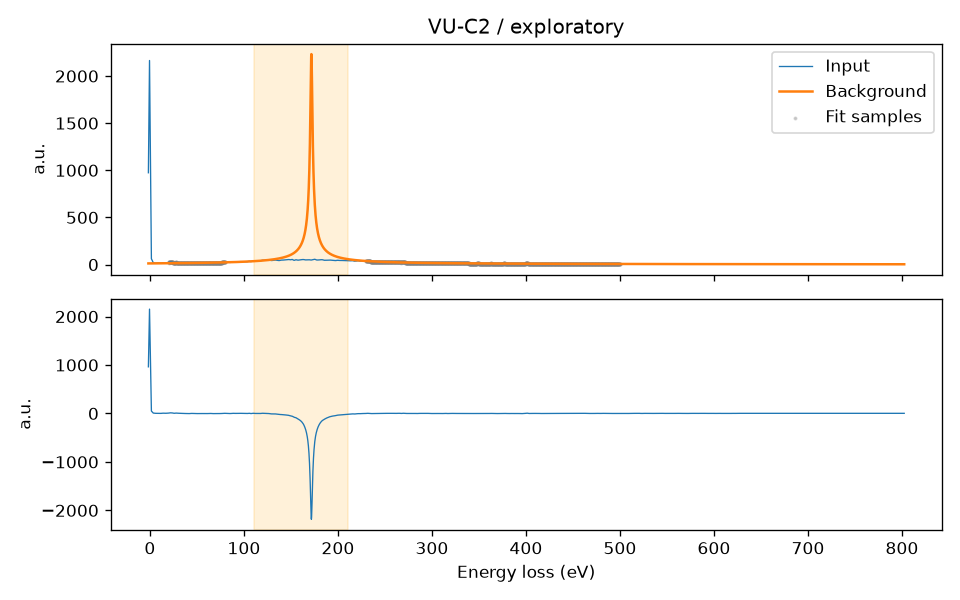

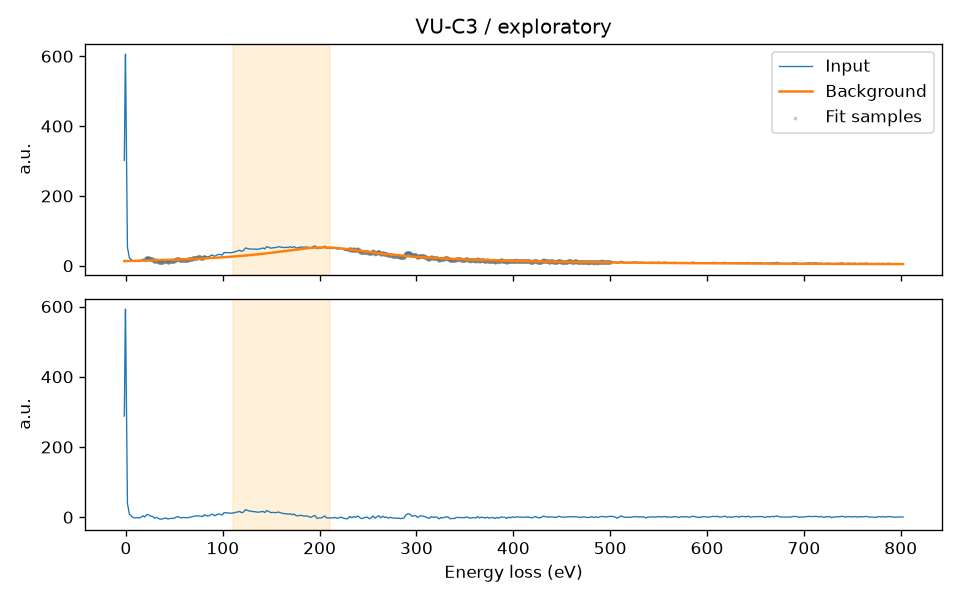

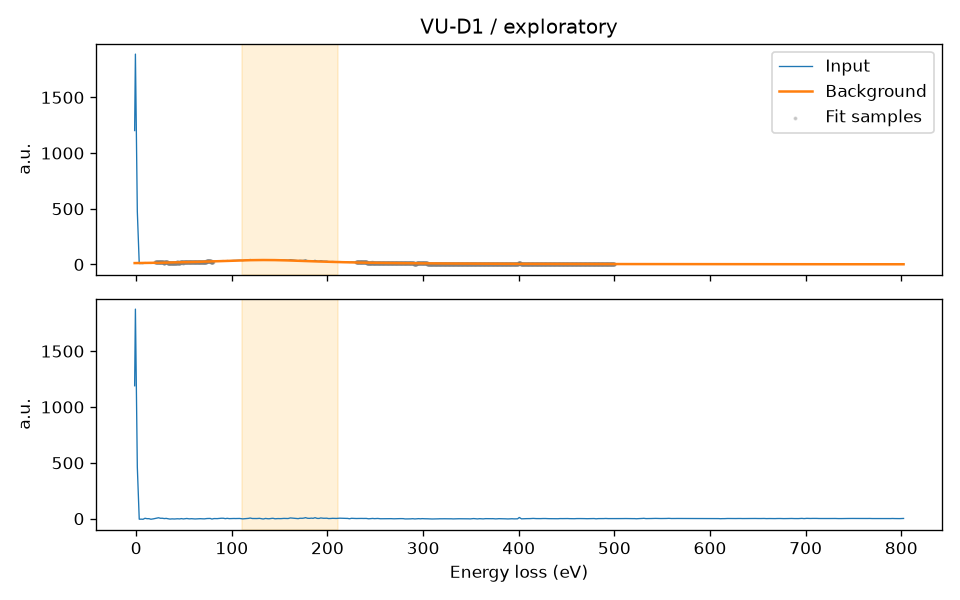

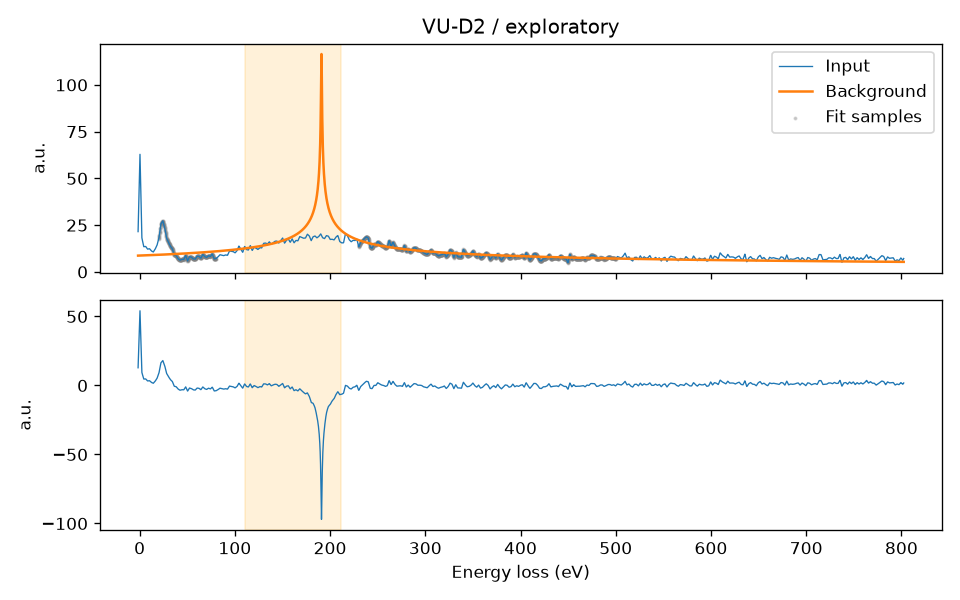

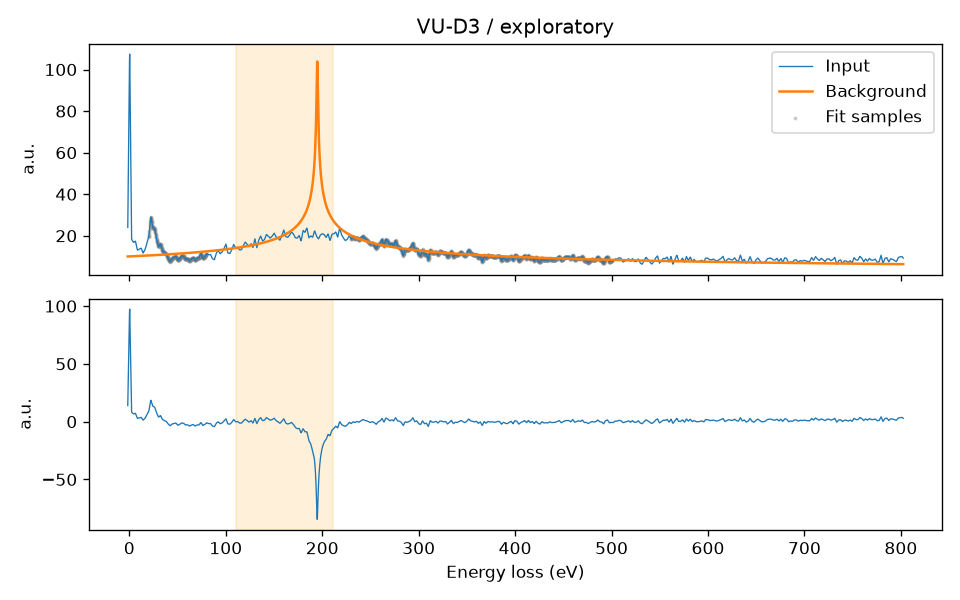

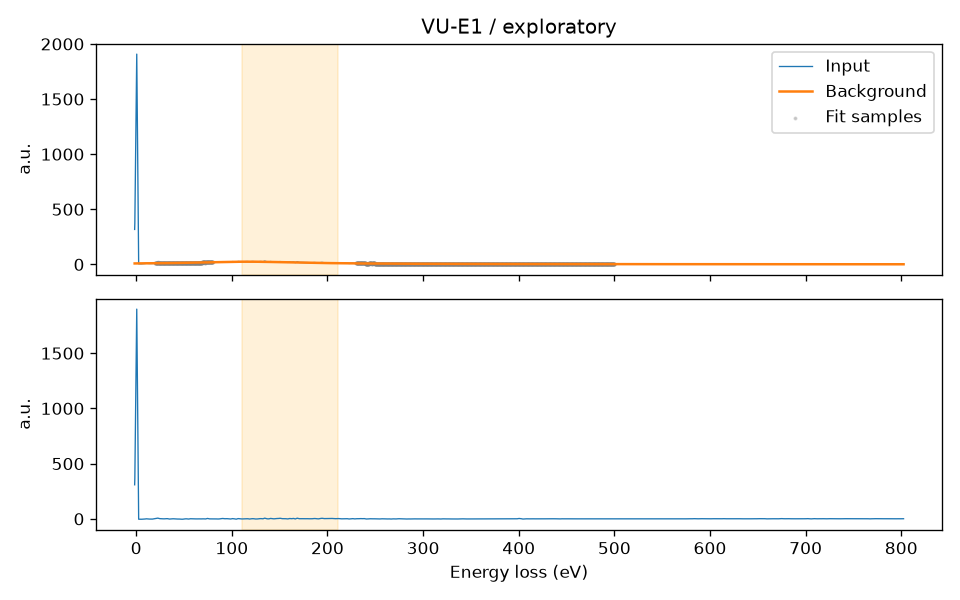

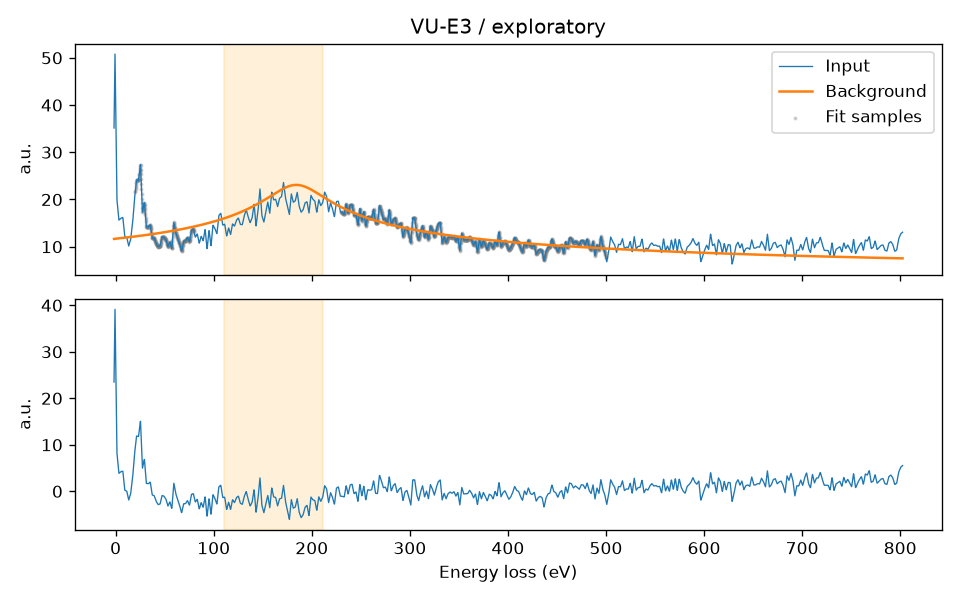

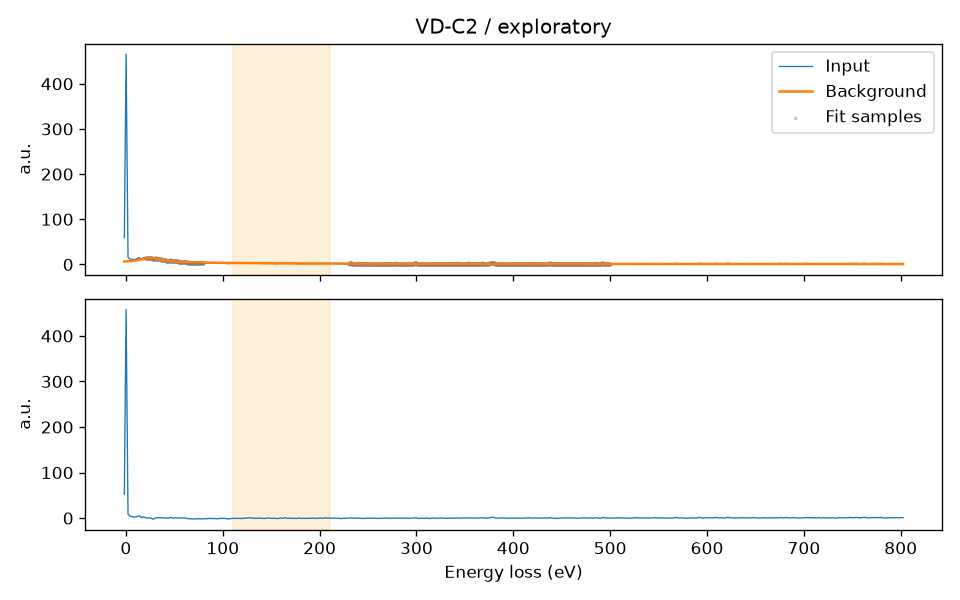

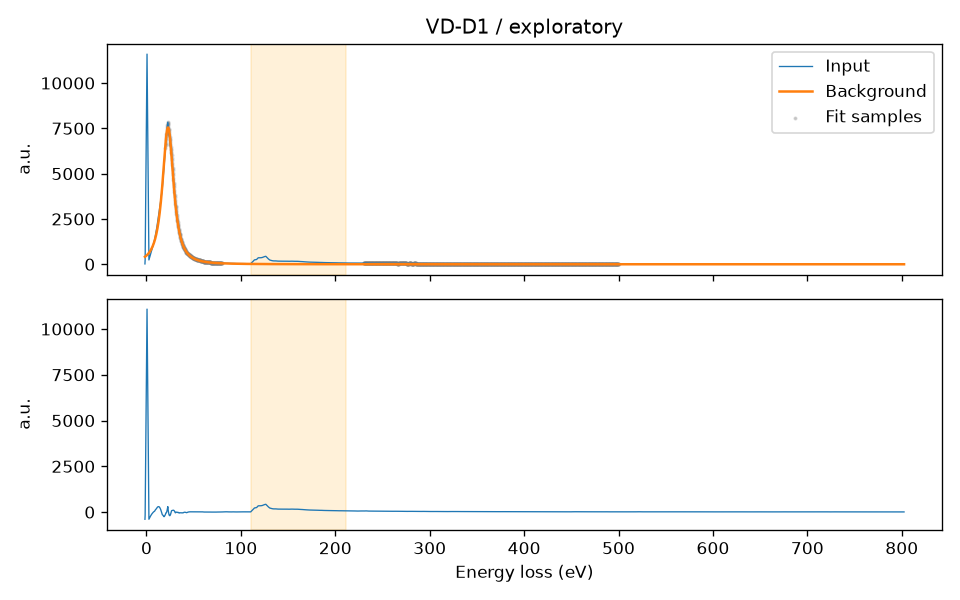

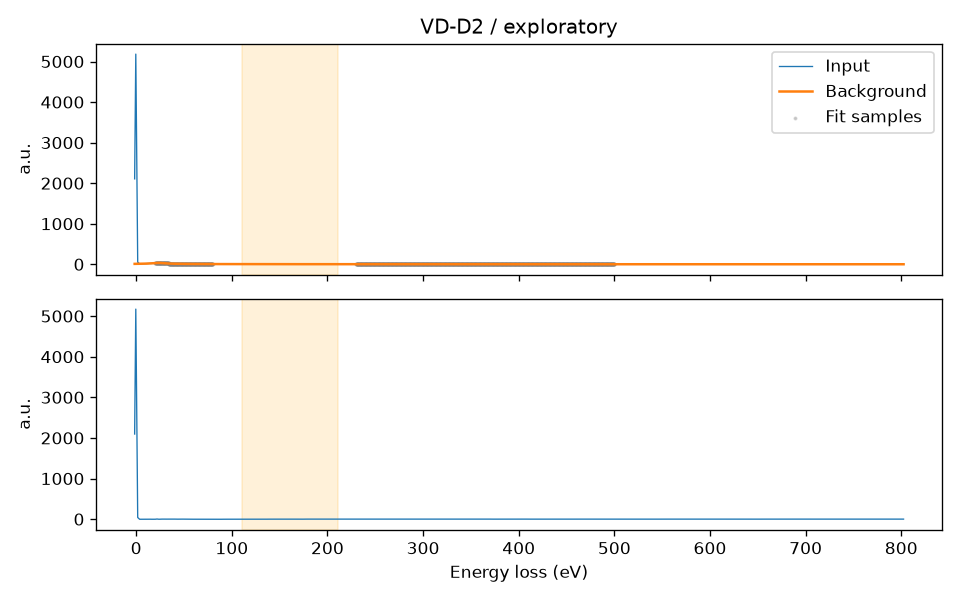

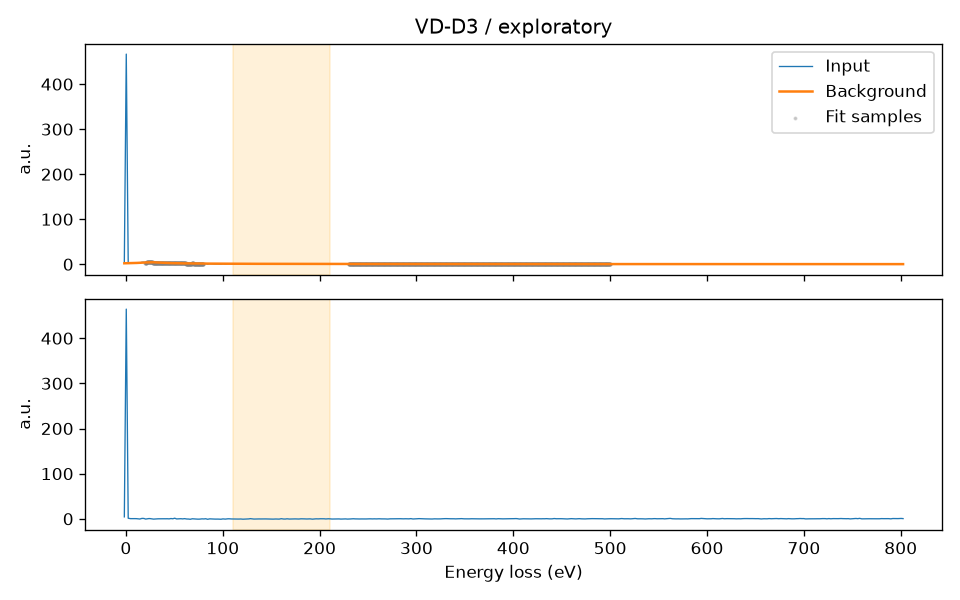

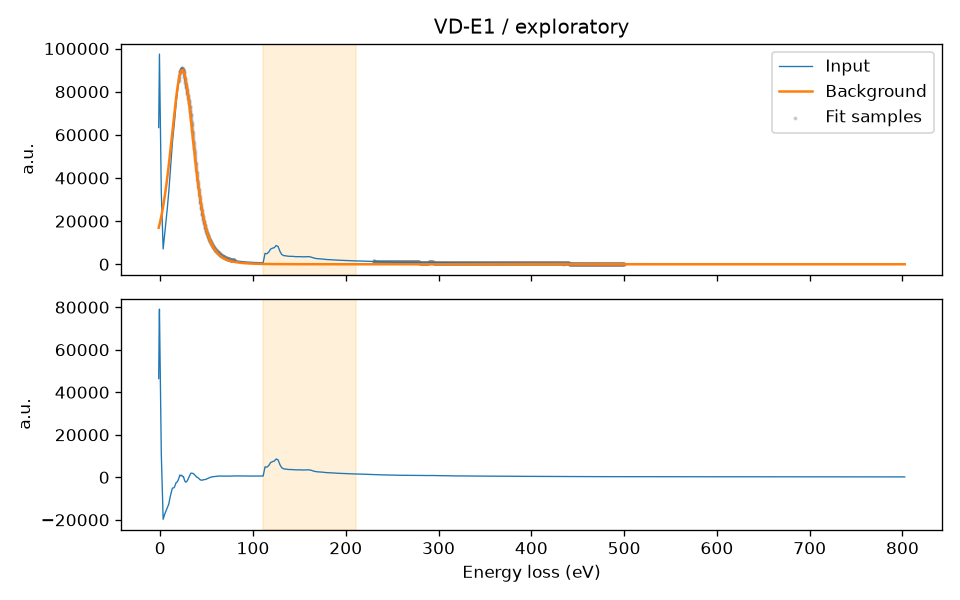

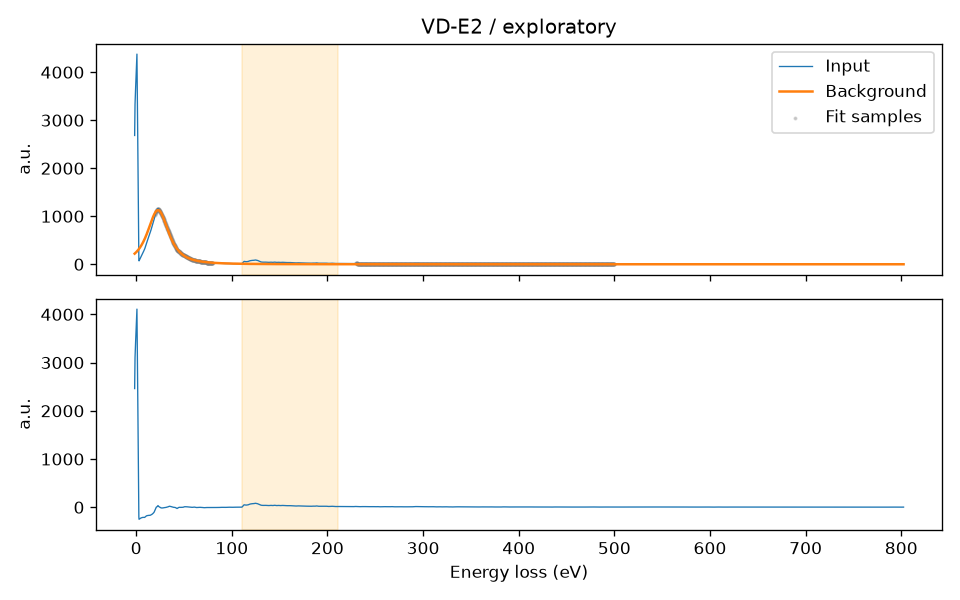

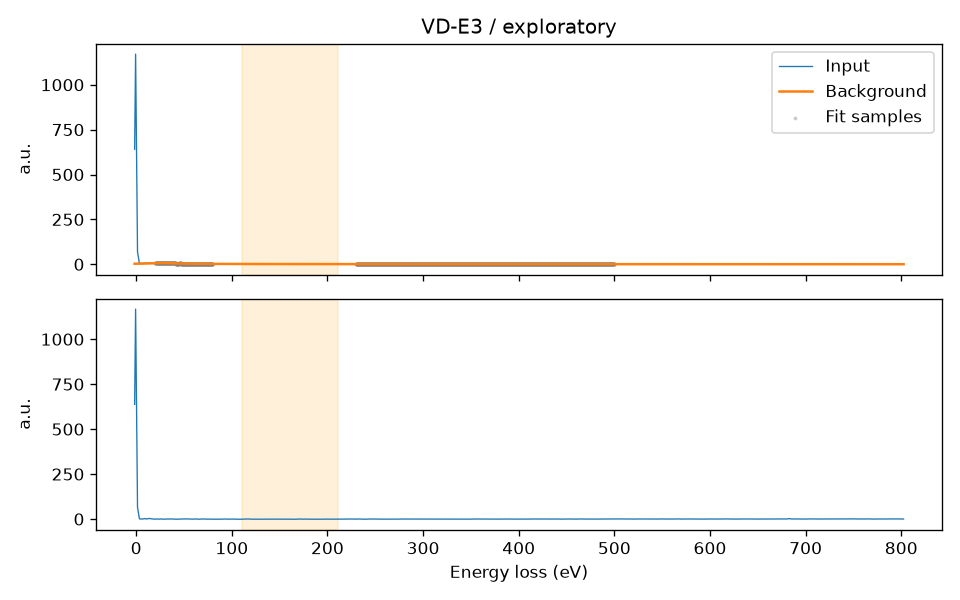

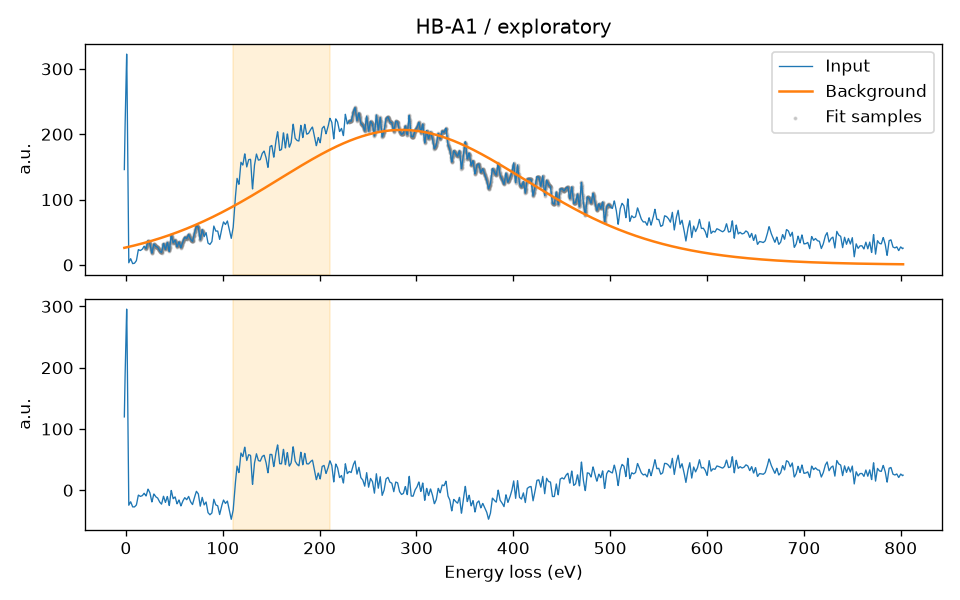

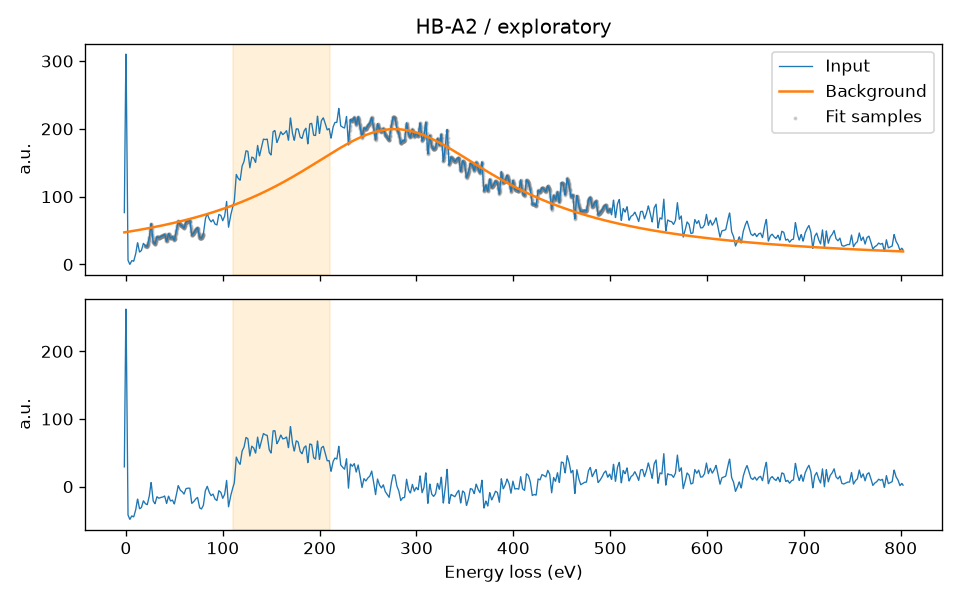

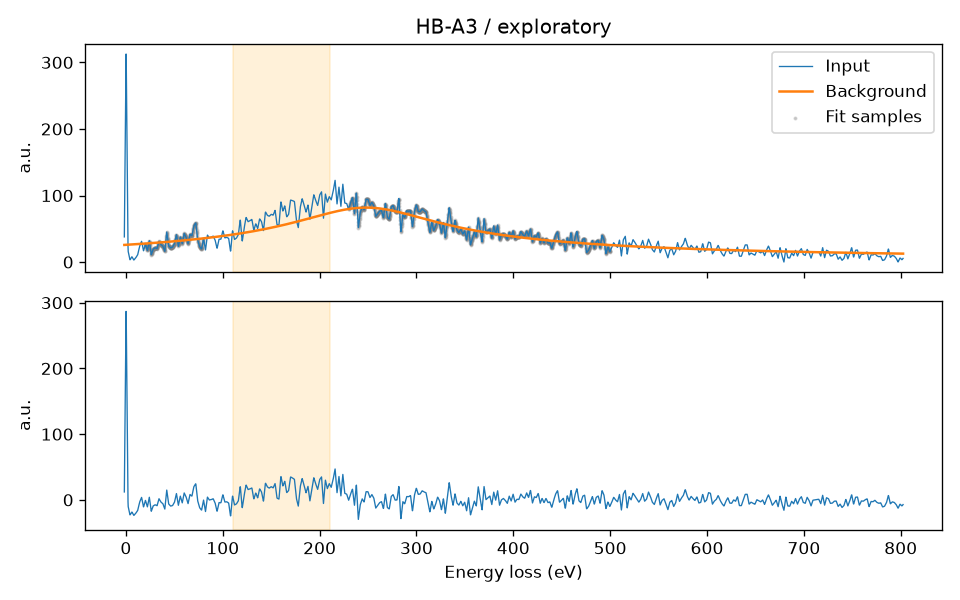

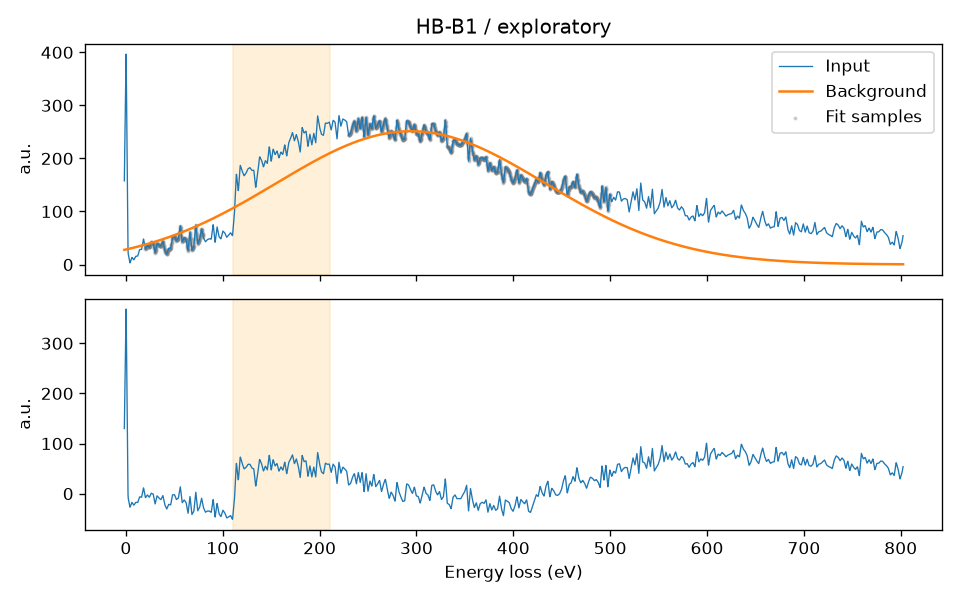

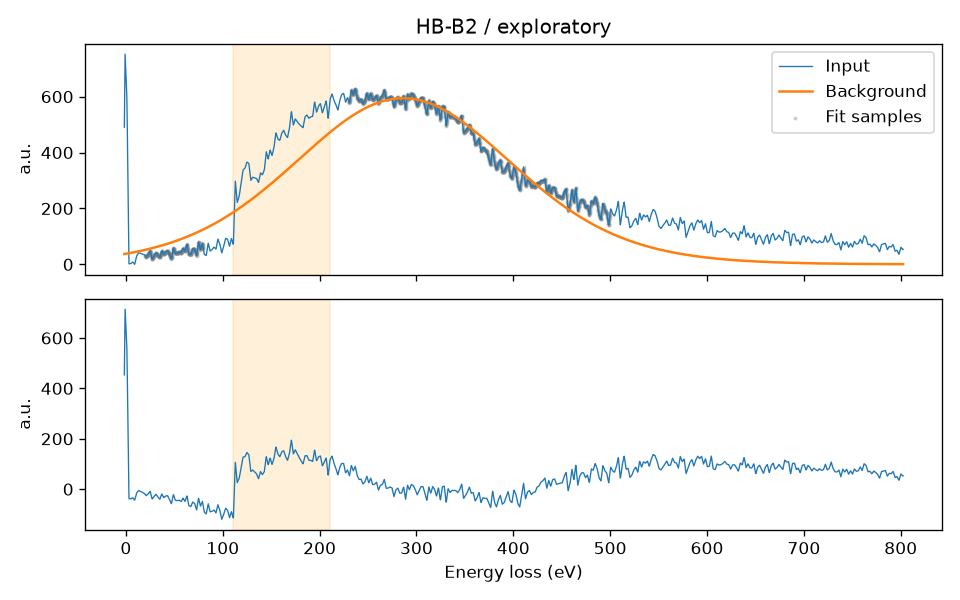

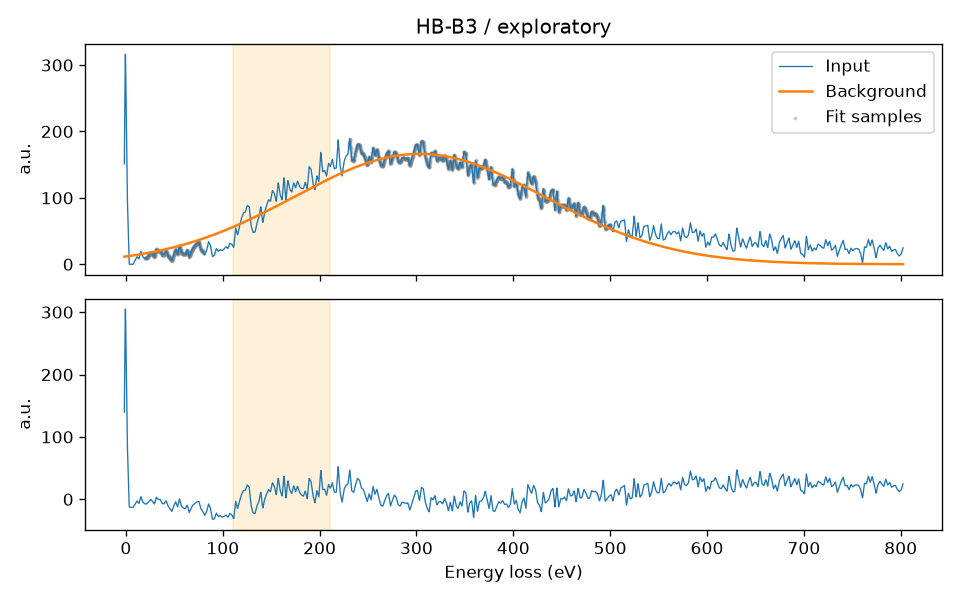

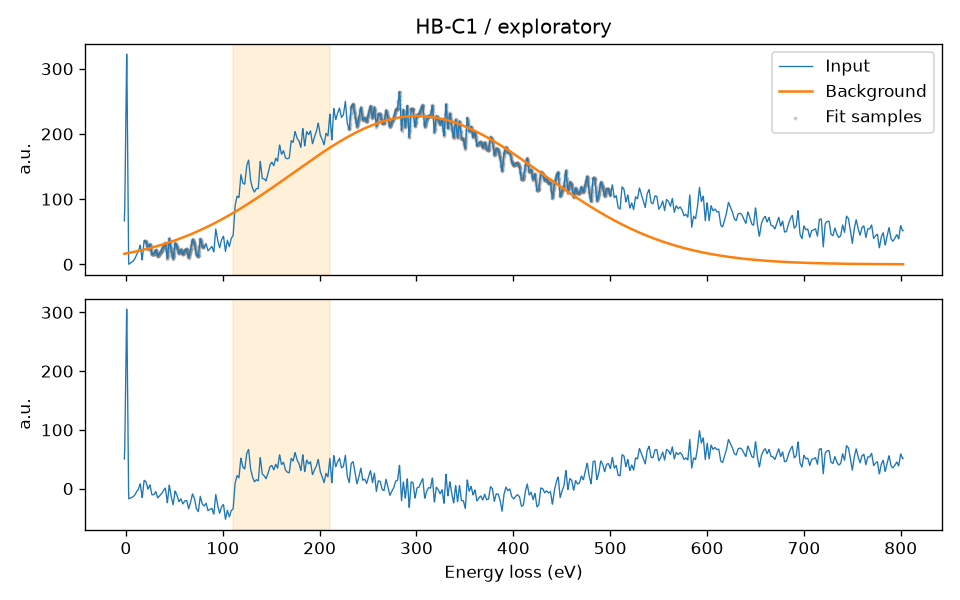

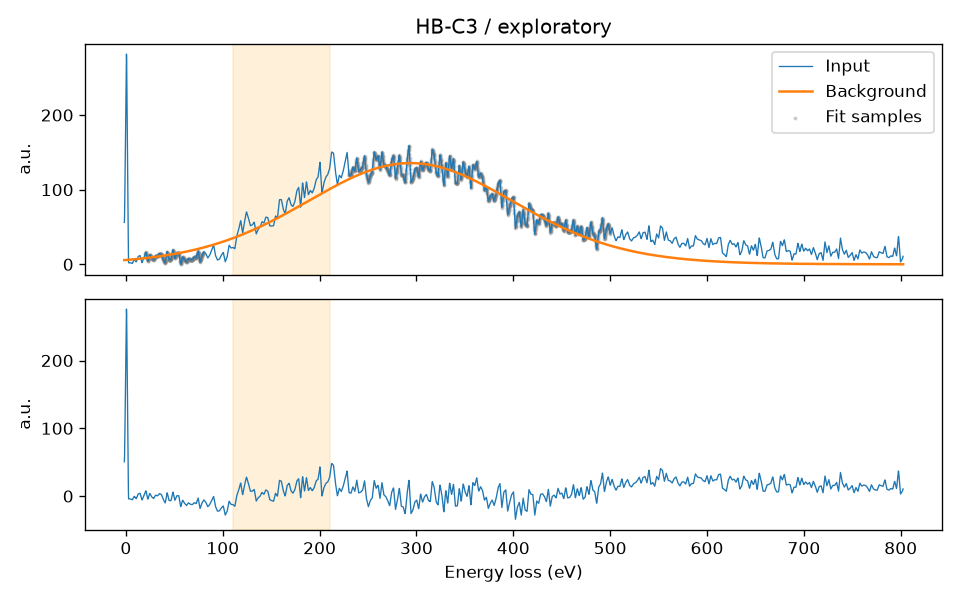

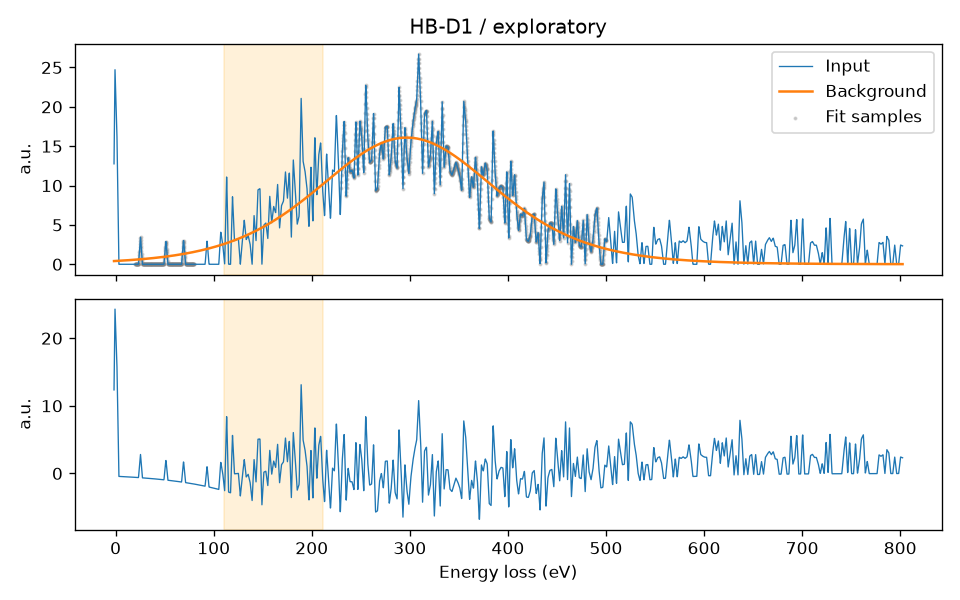

In [17]:
def plot_result(label, energy, intensity, result, directory, edge):
    fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
    axes[0].plot(energy, intensity, lw=.8, label="Input")
    axes[0].plot(energy, result["background"], label="Background")
    axes[0].scatter(energy[result["fit_mask"]], intensity[result["fit_mask"]],
                    s=2, color="gray", alpha=.3, label="Fit samples")
    axes[1].plot(energy, result["residual"], lw=.8, label="Extracted target")
    if "target_hf" in result:
        axes[1].plot(energy, result["target_hf"], "--", label="Target HF retained")
        axes[1].legend()
    for ax in axes:
        ax.axvspan(*edge, alpha=.15, color="orange")
    axes[0].legend()
    axes[0].set(title=label + " / exploratory", ylabel="Intensity (a.u.)")
    unit = "HF model / eV" if "intensity_unit" in result else "a.u."
    axes[0].set_ylabel(unit)
    axes[1].set(xlabel="Energy loss (eV)", ylabel=unit)
    fig.tight_layout()
    fig.savefig(directory / f"{label}.png", dpi=120)
    plt.close(fig)

outcomes = []
for record in records:
    label = record["crystal"]
    s, q = spectra[label], record["q_au"]
    energy, intensity = s.energy_loss_ev, s.counts
    if record["all_zero"] or record["group"] == "boundary":
        outcomes.append({"crystal": label, "status": "excluded", "reason": "zero or boundary"})
        continue
    if record["group"] == "mid_high_q" and reference is None:
        outcomes.append({"crystal": label, "status": "paused", "reason": "HF/reference unavailable"})
        continue
    try:
        if record["group"] == "low_q":
            result = fit_unweighted_pearson(energy, intensity, WINDOWS, EDGE)
        else:
            hf = make_hf(energy, q)
            mapped, available = map_available(reference[0], energy, q)
            result = extract_hf_target(energy, intensity, hf, mapped,
                windows=WINDOWS, edge=EDGE, prenorm_windows=PRENORM_WINDOWS,
                fit_linear=HF["fit_linear"])
            intensity = result["normalized_intensity"]
        save_result(REAL, label, energy, intensity, result, edge=EDGE,
                    provenance={**provenance, "crystal": record, "HF": HF, "atomic_source": atomic_metadata,
                                "fit_windows_eV": WINDOWS,
                                "reference": reference_metadata,
                                "hf_energy": hf.metadata if record["group"] == "mid_high_q" else None})
        plot_result(label, energy, intensity, result, REAL, EDGE)
        outcomes.append({"crystal": label, "status": "exploratory", "model": result["model"],
                         "fit_rmse": result["fit_rmse"],
                         "units": result.get("intensity_unit", "arbitrary units")})
    except (ValueError, FloatingPointError) as exc:
        outcomes.append({"crystal": label, "status": "failed", "reason": str(exc)})
display(pd.DataFrame(outcomes))
pd.DataFrame(outcomes).to_csv(REAL / "channel-status.csv", index=False)
# 显示每个成功通道的图；对应 PNG 与 CSV 已分别保存。
from IPython.display import Image
for outcome in outcomes:
    if outcome["status"] == "exploratory":
        display(Image(filename=str(REAL / (outcome["crystal"] + ".png"))))


## 7 每个模组及全部模组的目标区平均
高q结果除以保存的 raw_to_hf_scale，恢复到与低q一致的输入强度单位后平均。
模组内有效晶体等权。总体主曲线为模组均值等权平均；虚线为全部晶体等权平均。
这是跨q的描述性平均，不包含探测效率或绝对强度校准；不生成统计误差条。
保留负值，排除全零/失败通道，缺失点不补0，逐点保存实际贡献数。



注意：以下通道的目标区扣除结果异常大，仍保留在平均中。


,crystal,module,reason,peak_ratio,action
0,HL-E1,HL,target residual exceeds 10 times input peak; i...,17720.866450,retained in mean; diagnostic only
1,HL-E2,HL,target residual exceeds 10 times input peak; i...,13940.014988,retained in mean; diagnostic only
2,HL-E3,HL,target residual exceeds 10 times input peak; i...,699.600547,retained in mean; diagnostic only
3,VU-C2,VU,target residual exceeds 10 times input peak; i...,38.798116,retained in mean; diagnostic only


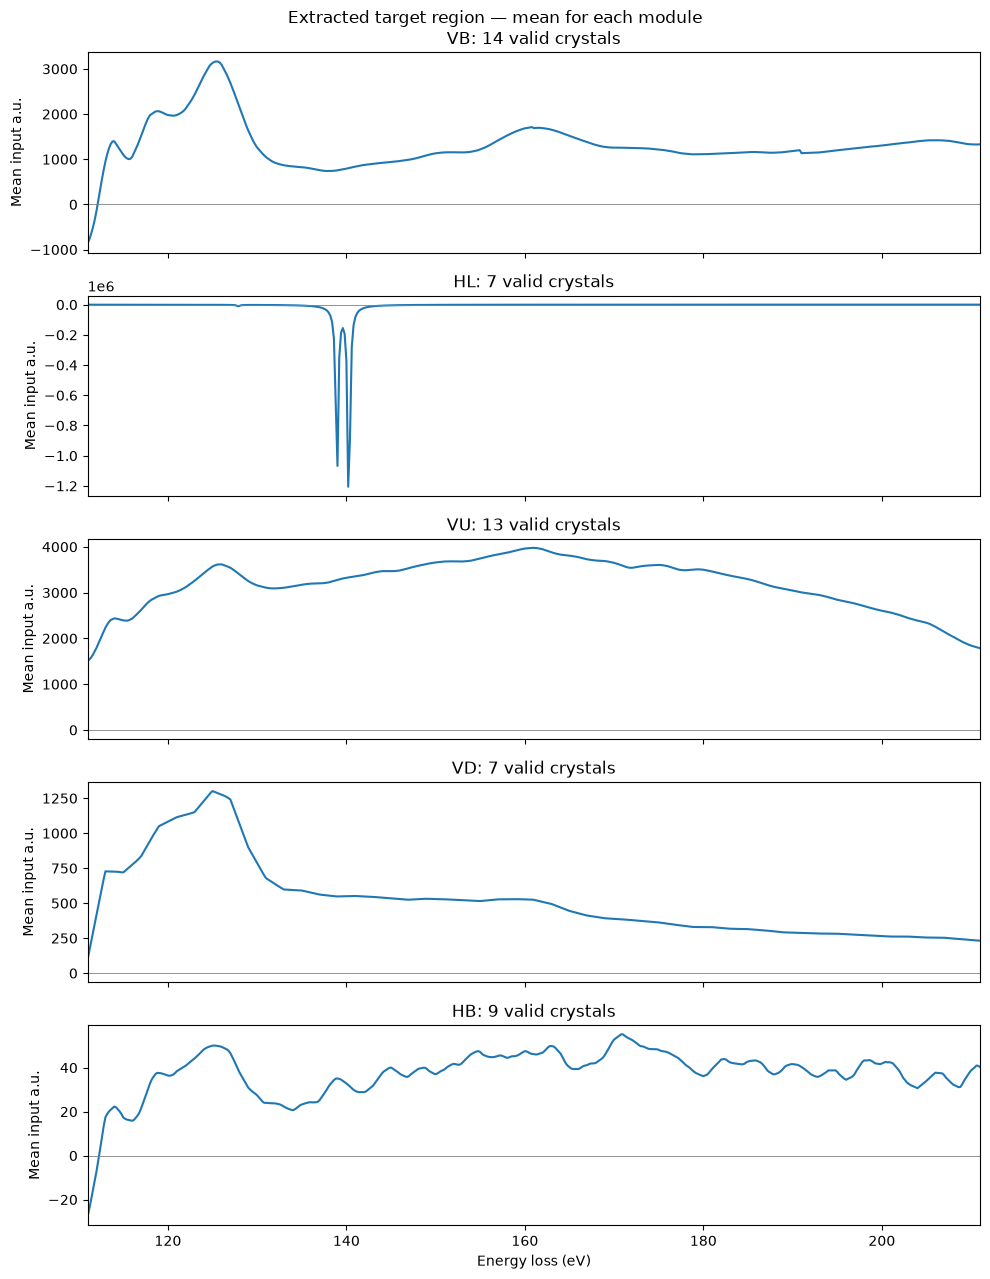

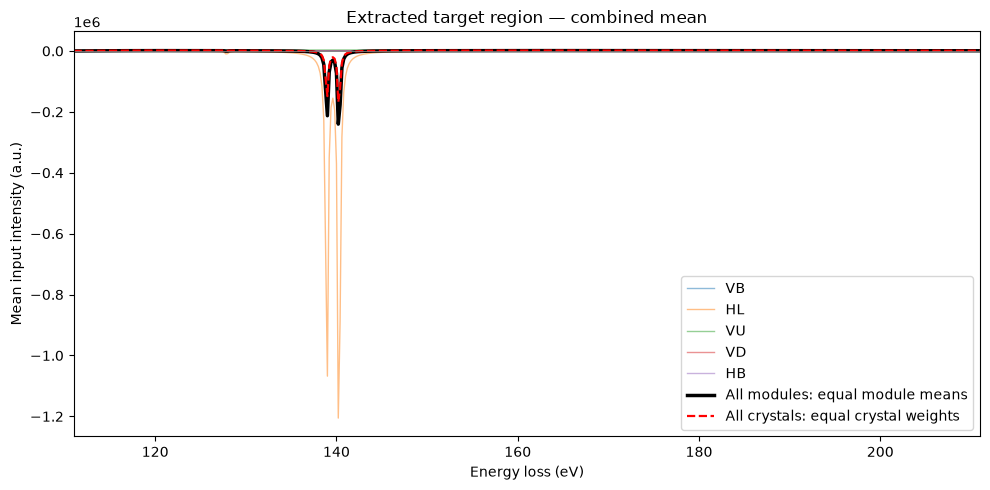

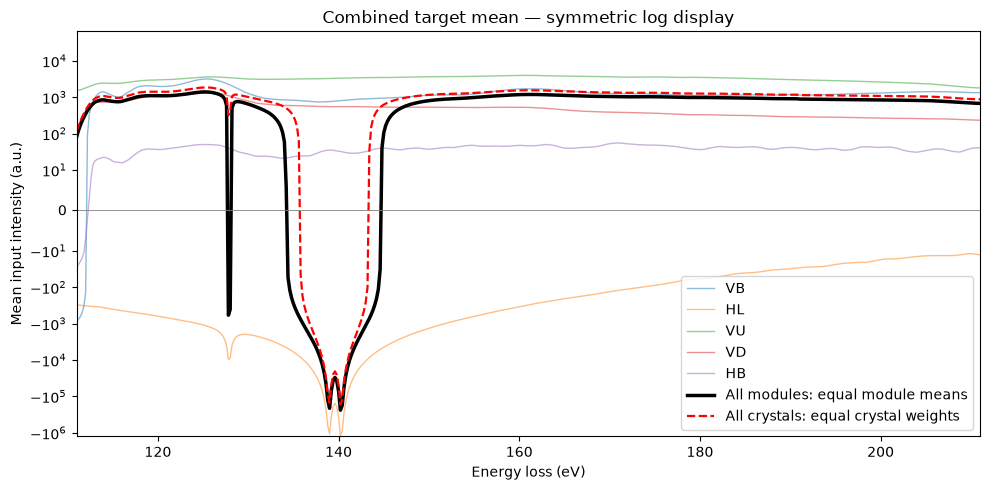

,module,included_crystals,min_contributors,max_contributors
0,VB,14,14,14
1,HL,7,7,7
2,VU,13,13,13
3,VD,7,7,7
4,HB,9,9,9


模组平均图、CSV与权重说明: C:\Users\a1566\Documents\Work\python\xrsabre\xrs-compton-extraction\output\ho-b4-hf-matching\real\module-averages


In [18]:
from xrs_compton_extraction.module_averages import average_target_exports, export_target_averages

TARGET_VIEW = EDGE  # 仅控制展示和平均，不改变拟合
AVERAGES = REAL / "module-averages"
averages = average_target_exports(REAL, records, target_window=TARGET_VIEW)
export_target_averages(averages, AVERAGES)
if averages["metadata"]["warnings"]:
    print("注意：以下通道的目标区扣除结果异常大，仍保留在平均中。")
    display(pd.DataFrame(averages["metadata"]["warnings"]))
average_energy = averages["energy_ev"]
module_items = list(averages["modules"].items())

fig, axes = plt.subplots(len(module_items), 1, figsize=(10, 2.6*len(module_items)), sharex=True)
for ax, (module, values) in zip(np.atleast_1d(axes), module_items):
    ax.plot(average_energy, values["mean"], lw=1.5)
    ax.axhline(0, color="gray", lw=.6)
    ax.set(title=f"{module}: {values['total_crystals']} valid crystals",
           ylabel="Mean input a.u.", xlim=TARGET_VIEW)
np.atleast_1d(axes)[-1].set_xlabel("Energy loss (eV)")
fig.suptitle("Extracted target region — mean for each module")
fig.tight_layout()
fig.savefig(AVERAGES / "module-target-means.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
for module, values in module_items:
    ax.plot(average_energy, values["mean"], lw=1, alpha=.5, label=module)
ax.plot(average_energy, averages["module_equal_mean"], color="black", lw=2.5,
        label="All modules: equal module means")
ax.plot(average_energy, averages["crystal_equal_mean"], "--", color="red", lw=1.6,
        label="All crystals: equal crystal weights")
ax.axhline(0, color="gray", lw=.6)
ax.set(xlabel="Energy loss (eV)", ylabel="Mean input intensity (a.u.)", xlim=TARGET_VIEW,
       title="Extracted target region — combined mean")
ax.legend()
fig.tight_layout()
fig.savefig(AVERAGES / "all-modules-target-mean.png", dpi=160)
plt.show()

# 附加视图保留正负号，让异常尖峰之外的模组也能看清；不改变平均数据。
ax.set_yscale("symlog", linthresh=10)
ax.set_title("Combined target mean — symmetric log display")
fig.tight_layout()
fig.savefig(AVERAGES / "all-modules-target-mean-symlog.png", dpi=160)
display(fig)

display(pd.DataFrame([
    {"module": module, "included_crystals": values["total_crystals"],
     "min_contributors": int(values["n_crystals"].min()),
     "max_contributors": int(values["n_crystals"].max())}
    for module, values in module_items
]))
print("模组平均图、CSV与权重说明:", AVERAGES)


## 8. 独立合成验证
跨 q 示例以同一提取轮廓生成输入，验证目标 HF 保留和尺度恢复，不是物理模型验证。
独立测试另外检查一阶矩、阈值、扫描上限不变性和负结构保留。


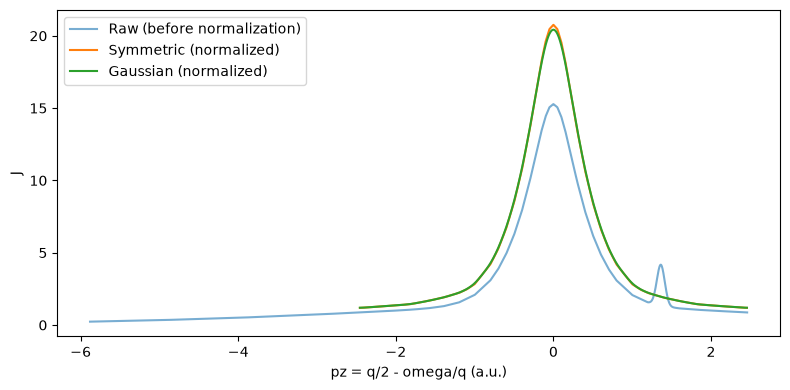

合成参考尺度恢复: 0.0003333333333333334


In [19]:
synthetic_q = 5.2
synthetic_energy = np.linspace(20, 1200, 2361)
synthetic_hf = make_hf(synthetic_energy, synthetic_q)
synthetic_peak = np.where((synthetic_energy >= EDGE[0]) & (synthetic_energy <= EDGE[1]),
                          .02*np.exp(-((synthetic_energy-175)/10)**2), 0.0)
synthetic_raw = 3000*(synthetic_hf.total + .002 + .000001*synthetic_energy + synthetic_peak)
syn_match = match_hf_scale(synthetic_energy, synthetic_raw, synthetic_hf.total,
    windows=WINDOWS, edge=EDGE, prenorm_windows=PRENORM_WINDOWS, fit_linear=True)
assert np.isclose(syn_match["metadata"]["raw_to_hf_scale"], 1/3000)
synthetic_candidate = ValenceReferenceCandidate(
    "synthetic_HoB4", synthetic_energy, syn_match["calibrated"], synthetic_q,
    (synthetic_energy >= EDGE[0]) & (synthetic_energy <= EDGE[1]),
    core_background=synthetic_hf.core, provenance={"synthetic": True})
synthetic_profile, synthetic_stages = valence_stages(
    synthetic_candidate, synthetic_hf.metadata["valence_electron_count"], SMOOTH_SIGMA)
show_stages(synthetic_stages, SYNTHETIC)
(SYNTHETIC / "reference-matching.json").write_text(
    json.dumps(syn_match["metadata"], indent=2), encoding="utf-8")
print("合成参考尺度恢复:", syn_match["metadata"]["raw_to_hf_scale"])


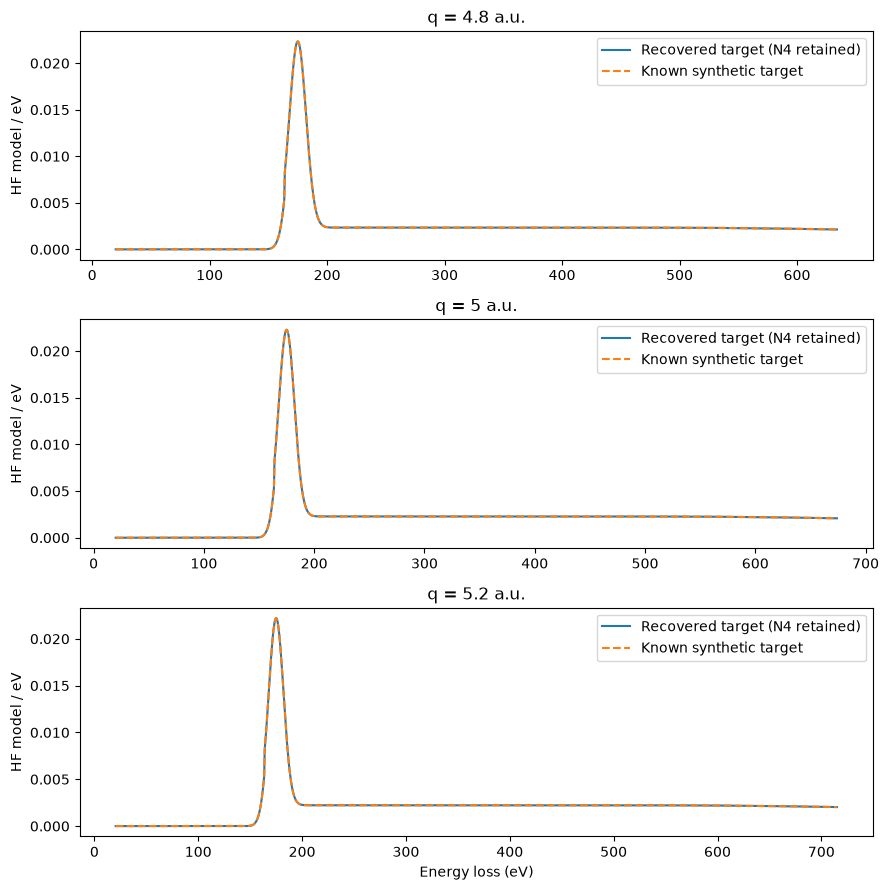

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(9, 9))
for q, ax in zip((4.8, 5.0, 5.2), axes):
    energy = np.linspace(20, 1000, 1961)
    mapped, available = map_available(synthetic_profile, energy, q)
    # 仅在已知支持内生成模拟数据，不用0替代未知尾部。
    energy, mapped = energy[available], mapped[available]
    hf = make_hf(energy, q)
    peak = np.where((energy >= EDGE[0]) & (energy <= EDGE[1]),
                    .02*np.exp(-((energy-175)/10)**2), 0.0)
    truth = hf.target + peak
    raw = 1800*(hf.core + mapped + peak + .003 + .000002*energy)
    result = extract_hf_target(energy, raw, hf, mapped,
        windows=WINDOWS, edge=EDGE, prenorm_windows=PRENORM_WINDOWS, fit_linear=True)
    assert np.allclose(result["residual"], truth, atol=1e-9)
    label = f"q-{q:g}"
    save_result(SYNTHETIC, label, energy, result["normalized_intensity"], result,
                edge=EDGE, provenance={"synthetic": True, "hf": hf.metadata})
    pd.DataFrame({"energy_eV": energy, "target_truth": truth}).to_csv(
        SYNTHETIC / f"{label}-truth.csv", index=False)
    plot_result(label, energy, result["normalized_intensity"], result, SYNTHETIC, EDGE)
    ax.plot(energy, result["residual"], label="Recovered target (N4 retained)")
    ax.plot(energy, truth, "--", label="Known synthetic target")
    ax.set(title=f"q = {q:g} a.u.", ylabel="HF model / eV")
    ax.legend()
axes[-1].set_xlabel("Energy loss (eV)")
fig.tight_layout()
fig.savefig(SYNTHETIC / "transfer-comparison.png", dpi=150)
plt.show()


## 9. 输出与边界
结果在 output/ho-b4-hf-matching，旧结果与迁移前 Notebook 保留。
hf-status.json 保存参考、尺度和基线及负轮廓诊断；channel-status.csv 保存所有通道状态。
N4 的164 eV为表内参考，原实验轴不移动；111–211 eV仍是探索保护区。
不外推价电子尾部。


In [21]:
import hashlib
assert all(hashlib.sha256(Path(path).read_bytes()).hexdigest() == digest
           for path, digest in provenance["input_sha256"].items())
assert hashlib.sha256(PROFILE_TABLE.read_bytes()).hexdigest() == source.provenance["source_sha256"]
manifest = {"purpose": "exploratory only", "reference": reference_metadata,
            "real_outcomes": outcomes, "input_sha256": provenance["input_sha256"],
            "real_directory": str(REAL), "synthetic_directory": str(SYNTHETIC)}
(OUTPUT / "manifest.json").write_text(
    json.dumps(manifest, indent=2, ensure_ascii=False), encoding="utf-8")
print("原始输入哈希未改变。输出:", OUTPUT)


原始输入哈希未改变。输出: C:\Users\a1566\Documents\Work\python\xrsabre\xrs-compton-extraction\output\ho-b4-hf-matching
